In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.geoaxes import GeoAxes
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [3]:
from xmip.preprocessing import combined_preprocessing
import regionmask
from xmip.regionmask import merged_mask
import warnings
import matplotlib.pyplot as plt
import numpy as np
import glob
import xarray as xr
import xbudget
import regionate
import xwmt
import xwmb
import xgcm
import matplotlib.colors as mcolors
import cmocean
import cartopy.crs as ccrs
from scipy.interpolate import PchipInterpolator
# import CM4Xutils #needed to run pip install nc-time-axis
# from regionate import MaskRegions, GriddedRegion
import sys
sys.path.insert(0, '/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/src')
from src import *
import matplotlib as mpl
import seaborn as sns
sns.set_theme(context='notebook', style='ticks')
mpl.rcParams['figure.dpi'] = 150

### Request HPC Resources

In [4]:
from dask_jobqueue import SLURMCluster  # setup dask cluster 
from dask.distributed import Client

log_directory="/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/logs"

cluster = SLURMCluster(
    cores=36,
    processes=1,
    memory='190GB',
    walltime='03:00:00',
    queue='compute',
    interface='ib0', 
log_directory = log_directory)
print(cluster.job_script())
cluster.scale(jobs=16)

client = Client(cluster)
client

#!/usr/bin/env bash

#SBATCH -J dask-worker
#SBATCH -e /vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/logs/dask-worker-%J.err
#SBATCH -o /vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/logs/dask-worker-%J.out
#SBATCH -p compute
#SBATCH -n 1
#SBATCH --cpus-per-task=36
#SBATCH --mem=177G
#SBATCH -t 03:00:00

/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter2/bin/python -m distributed.cli.dask_worker tcp://172.16.3.132:41498 --name dummy-name --nthreads 36 --memory-limit 176.95GiB --nanny --death-timeout 60 --interface ib0



Connection method: Cluster object,Cluster type: dask_jobqueue.SLURMCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://172.16.3.132:41498,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [5]:
native_path = "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/transient_tracers_z"
files = ["CM4Xp125_piControl_transient_tracers_z.zarr", "CM4Xp125_historical_transient_tracers_z.zarr", "CM4Xp125_ssp585_transient_tracers_z.zarr"]
full_depth_files = [native_path + "/" + a for a in files]

files = ["CM4Xp125_piControl_transient_tracers_surface.zarr", 
         "CM4Xp125_historical_transient_tracers_surface.zarr", 
         "CM4Xp125_ssp585_transient_tracers_surface.zarr"]
surface_files = [native_path + "/" + a for a in files]

In [6]:
def preprocess(ds):
    if ("year_ctrl" in ds.coords) or ("time_ctrl" in ds.coords):
        # if "time_ctrl" in ds.coords:
        #     ds = ds.reset_coords("year_ctrl", drop=True)
        # else:
        #     ds = ds.reset_coords("time_ctrl", drop=True)
        ds = ds.expand_dims(expt=["control"])
        ds.coords["year"] = ds.coords["year"]
        ds = ds.drop_vars(["year_ctrl"])
    else: 
        ds = ds.expand_dims(expt=["forced"])        
    return ds.isel(yh = slice(0, 150)).sel(year = slice(None, 2099))
ds_ctrl= xr.open_mfdataset(full_depth_files[0], combine="nested", concat_dim=["year"], parallel=True, preprocess=preprocess, engine = "zarr")
ds_forced = xr.open_mfdataset(full_depth_files[1:], combine="nested", concat_dim=["year"], parallel=True, preprocess=preprocess, engine = "zarr")

ds= xr.concat([ds_ctrl, ds_forced], dim = "expt")

In [7]:
z_i = np.array([0.000e+00, 5.000e+00, 1.500e+01, 2.500e+01, 4.000e+01, 6.250e+01,
       8.750e+01, 1.125e+02, 1.375e+02, 1.750e+02, 2.250e+02, 2.750e+02,
       3.500e+02, 4.500e+02, 5.500e+02, 6.500e+02, 7.500e+02, 8.500e+02,
       9.500e+02, 1.050e+03, 1.150e+03, 1.250e+03, 1.350e+03, 1.450e+03,
       1.625e+03, 1.875e+03, 2.250e+03, 2.750e+03, 3.250e+03, 3.750e+03,
       4.250e+03, 4.750e+03, 5.250e+03, 5.750e+03, 6.250e+03, 6.750e+03])
ds = ds.assign_coords({"z_i":z_i})

In [8]:
import xshelftransects

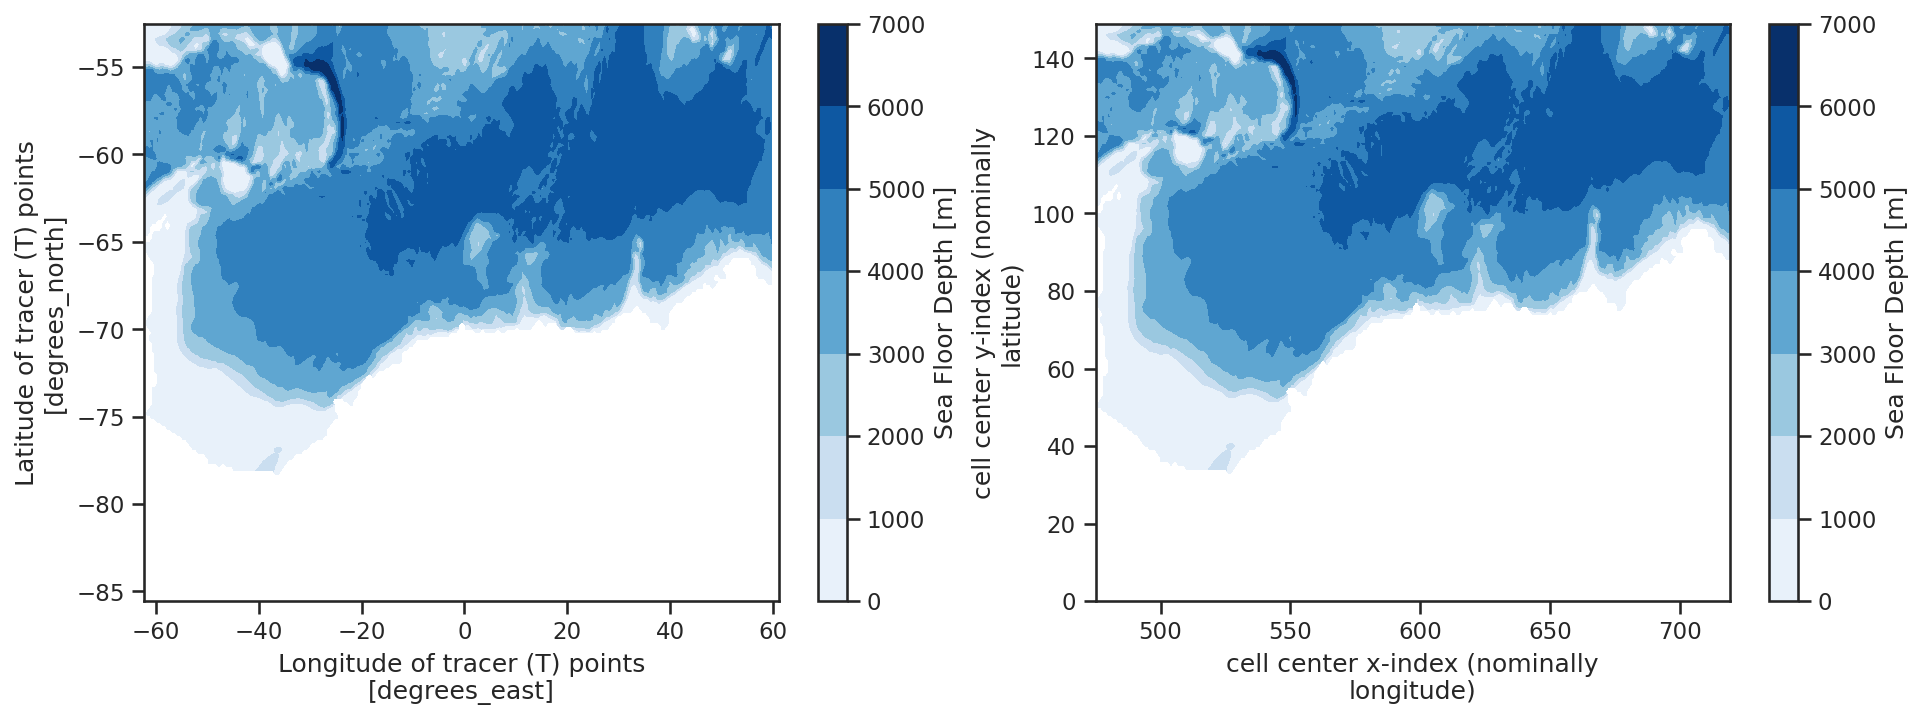

In [9]:
fig, ax = plt.subplots(1,2, figsize = (15, 5))
ds_subset = ds.isel(xh = slice(475, 1000))
ds_subset.deptho.plot.contourf(ax = ax[0], x = "geolon", y = "geolat", cmap = "Blues")
ds_subset.deptho.plot.contourf(ax = ax[1], cmap = "Blues")

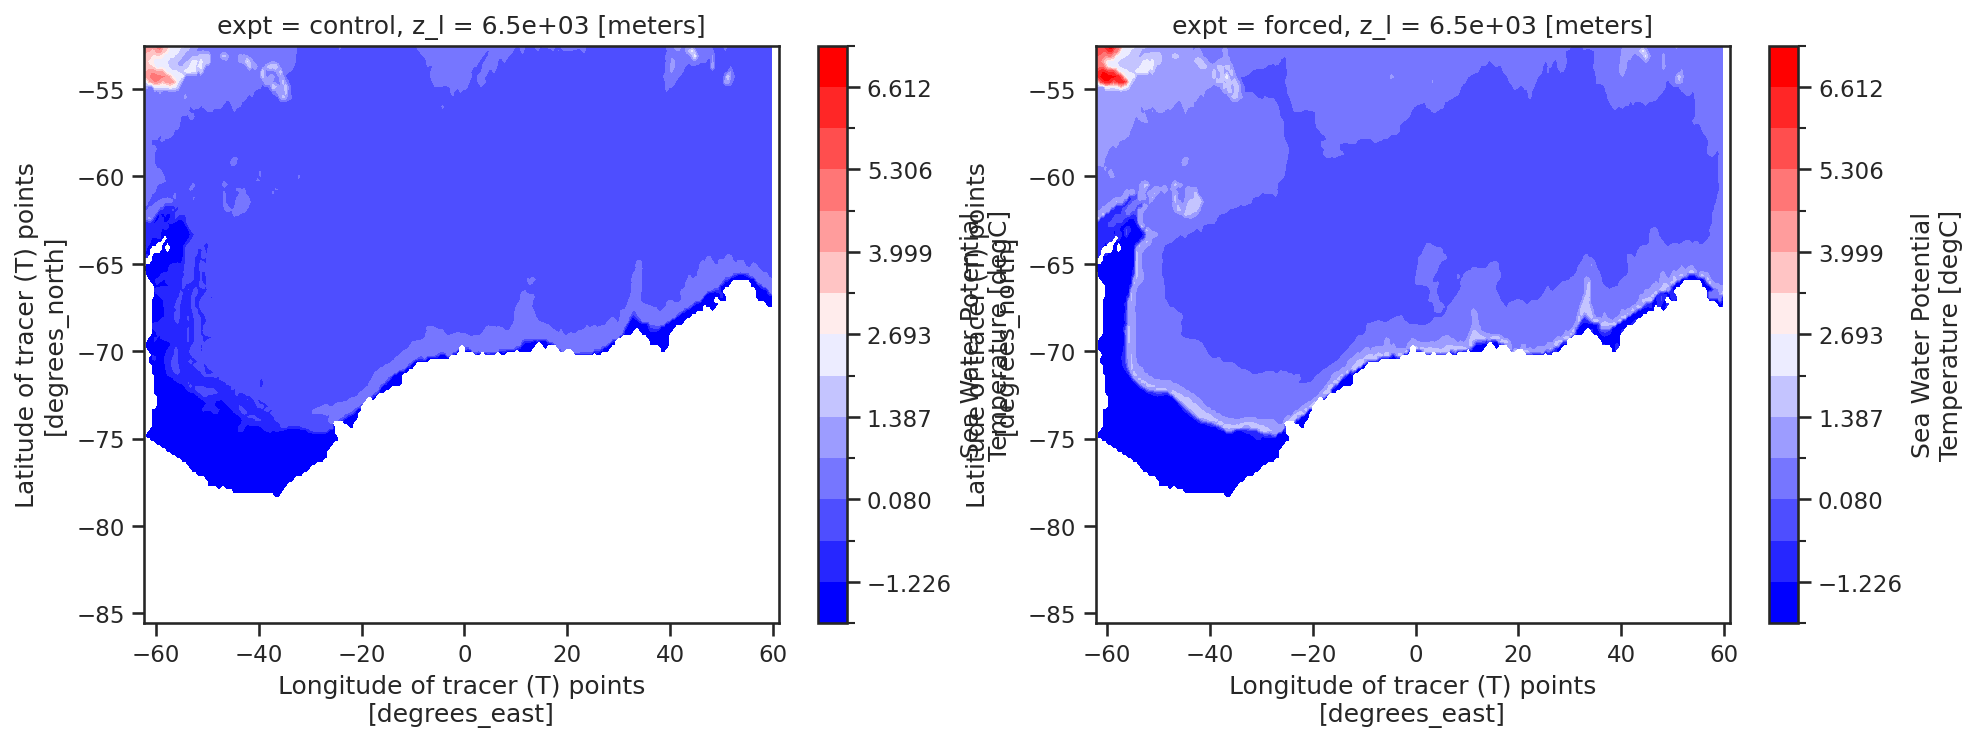

In [10]:
fig, ax = plt.subplots(1,2, figsize = (15, 5))
ds_subset = ds.isel(xh = slice(475, None)).isel(year = slice(-50, None)).mean("year").ffill("z_l")
ds_subset = ds_subset.thetao.isel(z_l = -1)
vmin = ds_subset.min().compute().values
vmax = ds_subset.max().compute().values

levels = np.linspace(vmin, vmax, 15)
ds_subset.isel(expt = 0).plot.contourf(ax = ax[0], x = "geolon", y = "geolat", 
                                       vmin = vmin, vmax = vmax, levels = levels, 
                                      cmap = "bwr")
ds_subset.isel(expt = 1).plot.contourf(ax = ax[1], x = "geolon", y = "geolat", 
                                       vmin = vmin, vmax = vmax, levels = levels, 
                                      cmap = "bwr")

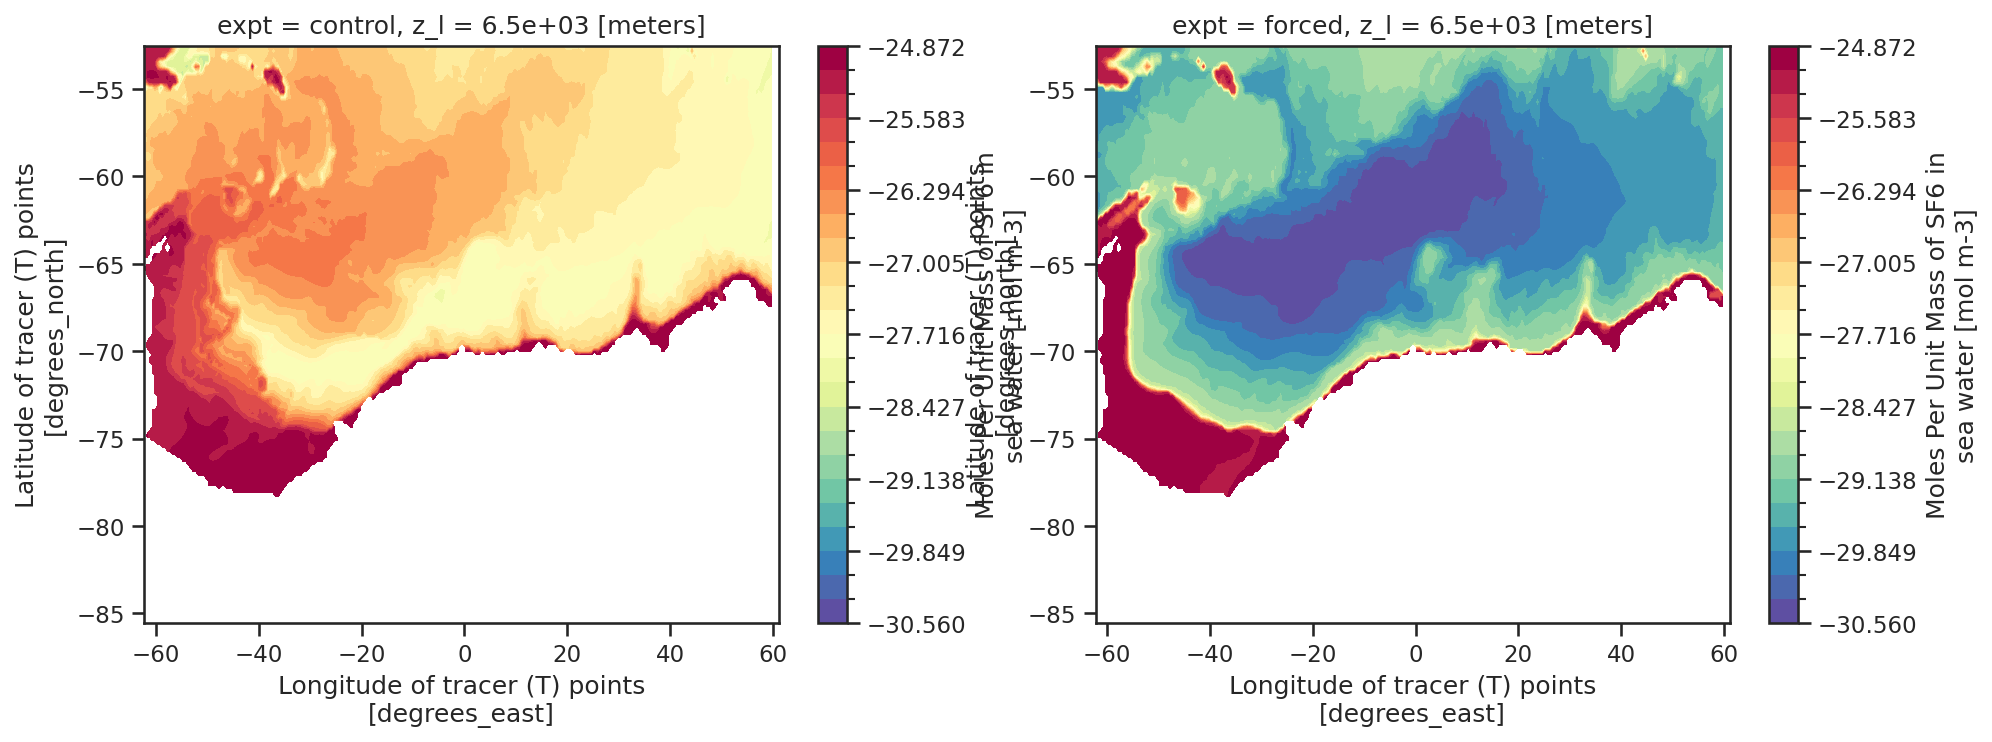

In [11]:
fig, ax = plt.subplots(1,2, figsize = (15, 5))
ds_subset = ds.isel(xh = slice(475, None)).isel(year = slice(-25, None)).mean("year").ffill("z_l")
ds_subset = np.log(ds_subset.sf6.isel(z_l = -1))
vmin = ds_subset.min().compute().values
vmax = ds_subset.max().compute().values

levels = np.linspace(vmin, vmax, 25)
ds_subset.isel(expt = 0).plot.contourf(ax = ax[0], x = "geolon", y = "geolat", 
                                       vmin = vmin, vmax = vmax, levels = levels, 
                                      cmap = "Spectral_r")
ds_subset.isel(expt = 1).plot.contourf(ax = ax[1], x = "geolon", y = "geolat", 
                                       vmin = vmin, vmax = vmax, levels = levels, 
                                      cmap = "Spectral_r")

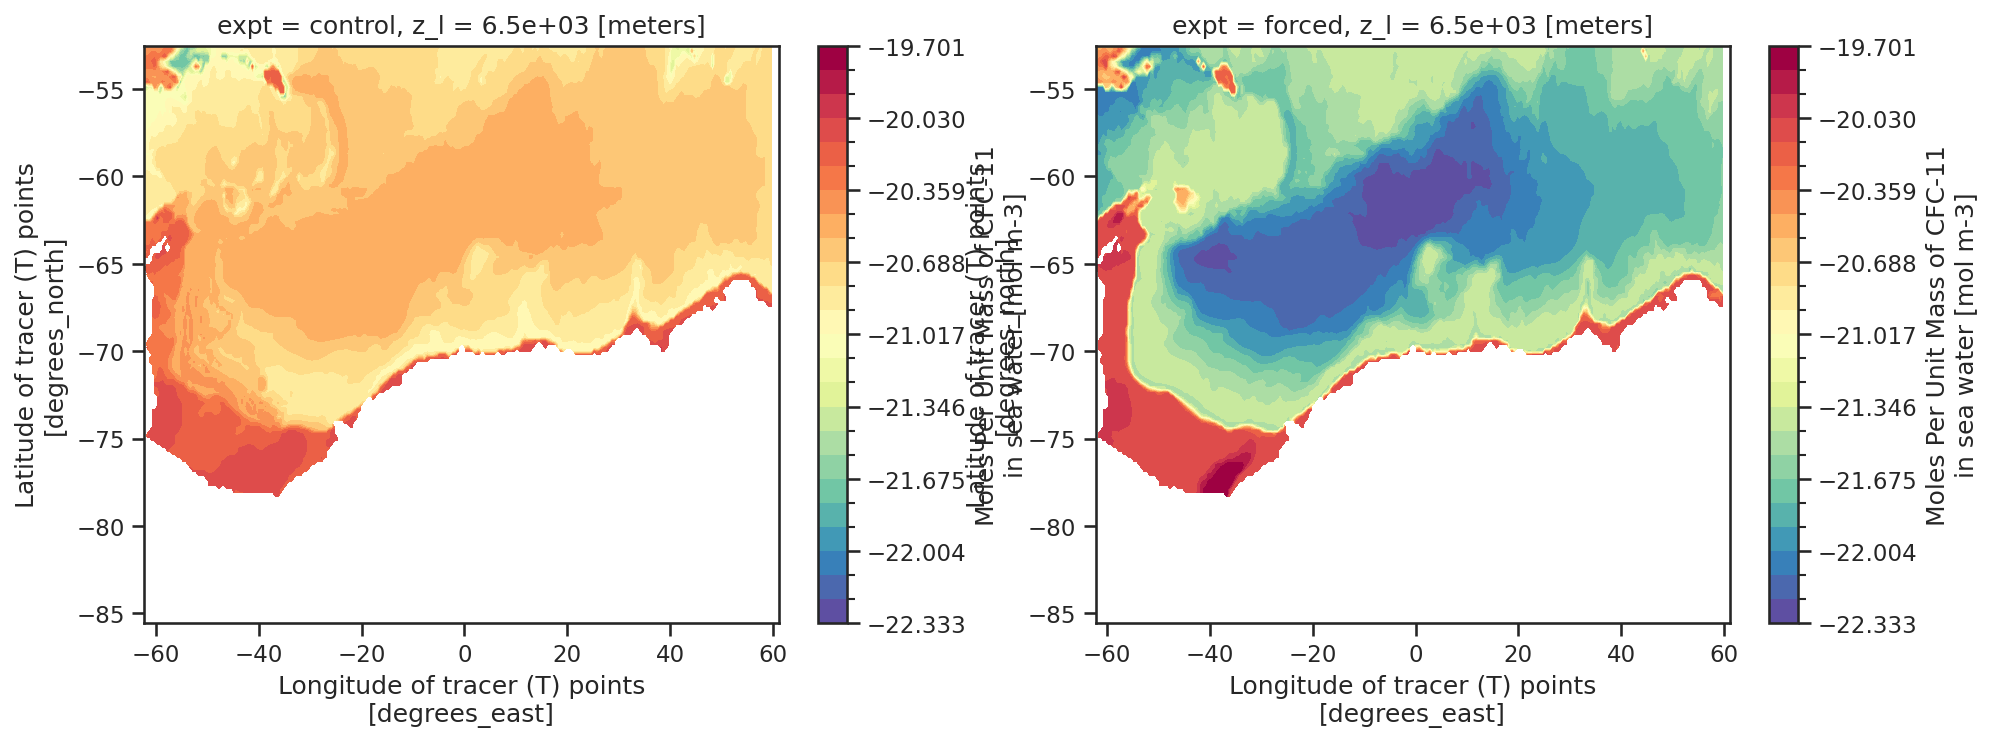

In [12]:
fig, ax = plt.subplots(1,2, figsize = (15, 5))
ds_subset = ds.isel(xh = slice(475, None)).isel(year = slice(-25, None)).mean("year").ffill("z_l")
ds_subset = np.log(ds_subset.cfc11.isel(z_l = -1))
vmin = ds_subset.min().compute().values
vmax = ds_subset.max().compute().values

levels = np.linspace(vmin, vmax, 25)
ds_subset.isel(expt = 0).plot.contourf(ax = ax[0], x = "geolon", y = "geolat", 
                                       vmin = vmin, vmax = vmax, levels = levels, 
                                      cmap = "Spectral_r")
ds_subset.isel(expt = 1).plot.contourf(ax = ax[1], x = "geolon", y = "geolat", 
                                       vmin = vmin, vmax = vmax, levels = levels, 
                                      cmap = "Spectral_r")

In [13]:
rename_geocoords = lambda ds: ds.rename({"lat":"old_lat", "lon":"old_lon"}).rename({"geolat":"lat", "geolon":"lon"})
ds_weddell = rename_geocoords(ds)
ds_weddell = ds_weddell.reset_coords(names='deptho')
ds_weddell = ds_weddell.isel(xh = slice(475, 600))
ds_weddell_zstar = 1 * ds_weddell

Inferring Z grid coordinate: depth `z_`


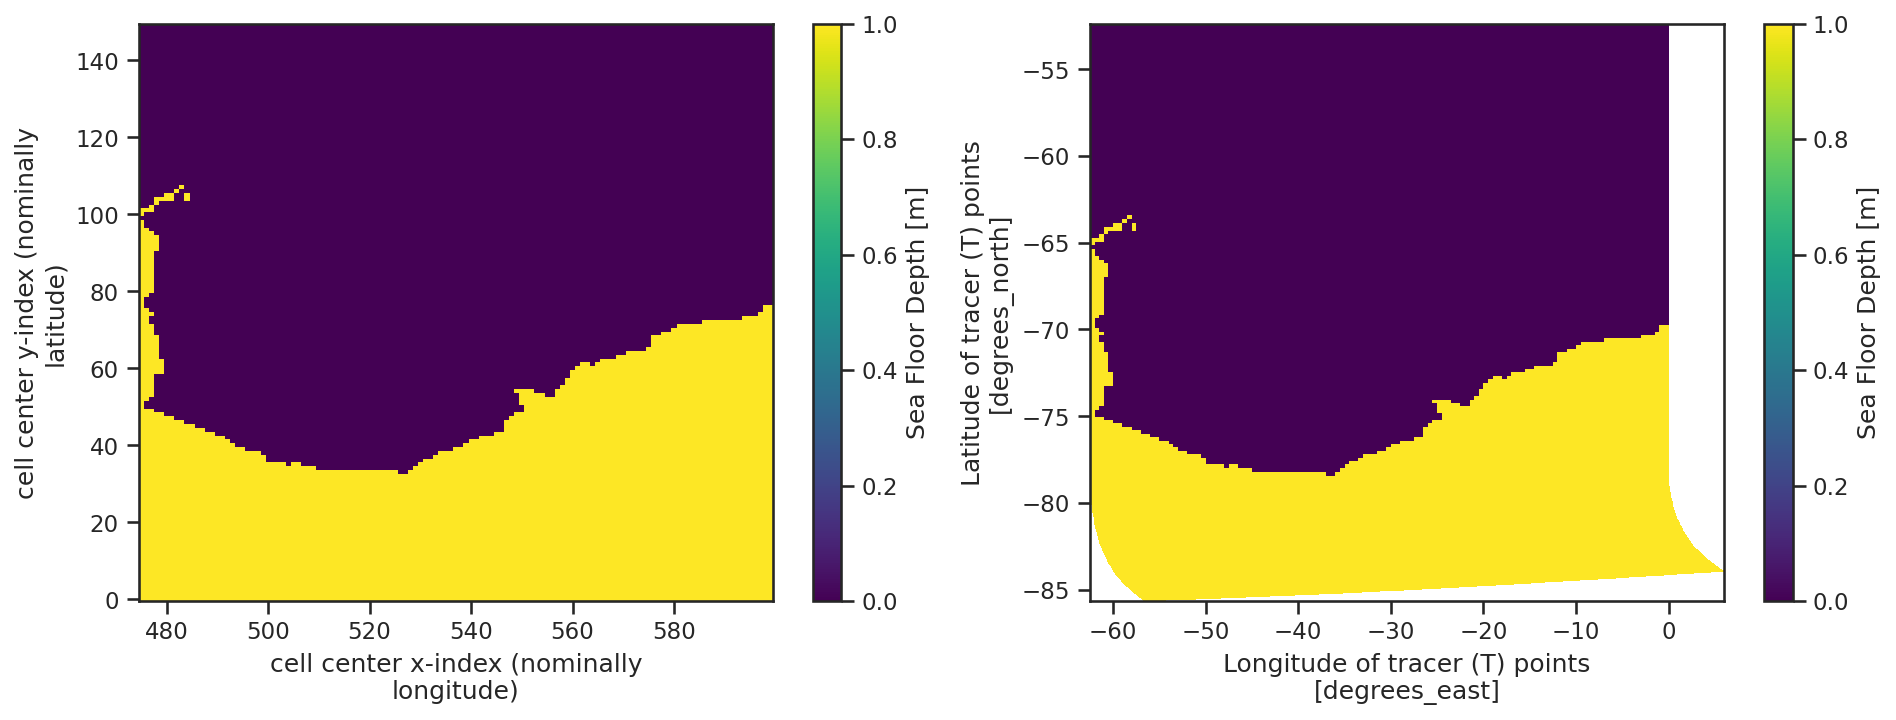

In [14]:
rename_geocoords = lambda ds: ds.rename({"lat":"old_lat", "lon":"old_lon"}).rename({"geolat":"lat", "geolon":"lon"})

ds_filtered = ds.where(ds.thkcello.fillna(0.0) > 0.0)
ds_remap = remap_vcoord_to_depth(ds_filtered, vcoord = "z", new_vcoord = "depth")
ds_weddell = rename_geocoords(ds_remap).rename({"depth_l":"z_l"})
ds_weddell = ds_weddell.reset_coords(names='deptho')
ds_weddell = ds_weddell.isel(xh = slice(475, 600))

fig, ax = plt.subplots(1,2, figsize = (15, 5))
boundary_mask = (ds_weddell.deptho.fillna(0.0) <= 0.0).compute()
boundary_mask.plot(ax = ax[0])
boundary_mask.plot(ax = ax[1], x = "lon", y = "lat")

In [15]:
transects, geometry = xshelftransects.cross_shelf_transects(
    ds_weddell,
    ["thetao", "cfc11", "sf6", "so", "sigma2_offline", "sigma2"],                    # str | list[str]
    boundary_mask,          # DataArray; contour(level=0.5) defines transect_length=0
    transect_length=np.arange(0.0, 12 * 100e3 + 2e3, 5.0e3),
    transect_spacing=40e3,
    crs="EPSG:3031",
    engine="xesmf",
    method="bilinear",
    lon_name="lon",
    lat_name="lat",
    return_geometry=True,
)


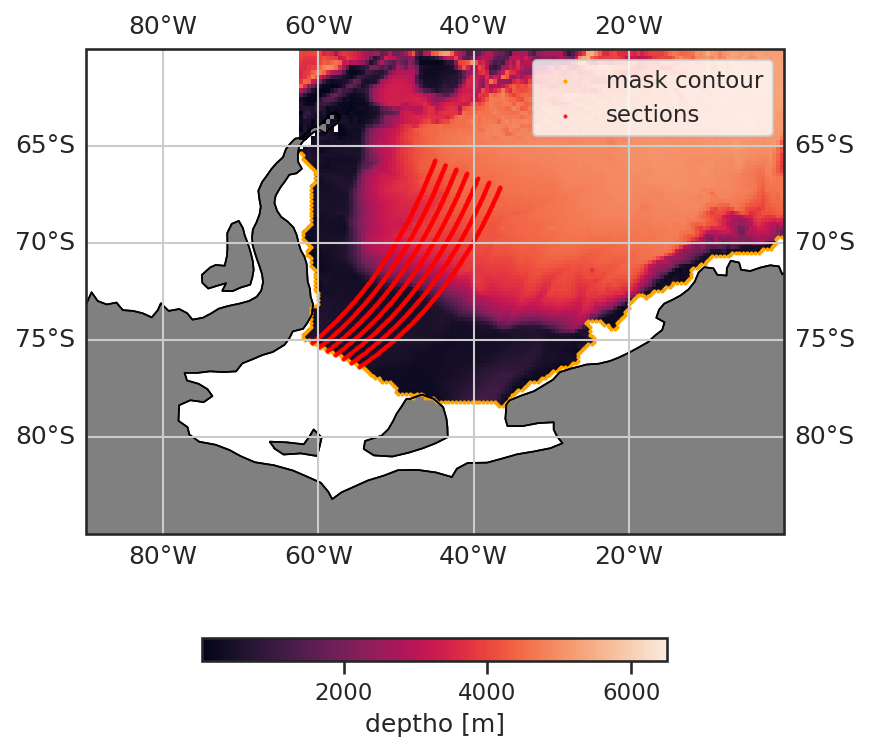

In [16]:
import cartopy.crs as ccrs
import cartopy
# # Plot geometry
fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
# ax = plt.axes(projection=ccrs.SouthPolarStereo())
# ax.set_extent([-180, 180, -90, -60], crs=ccrs.PlateCarree())
ax.set_extent([-90, 0, -85, -60], crs=ccrs.PlateCarree())
ax.coastlines(resolution="110m", linewidth=0.8)
ax.coastlines(resolution="110m", linewidth=0.8)
ax.add_feature(cartopy.feature.LAND.with_scale('110m'), facecolor='grey')

gl = ax.gridlines(draw_labels = True);

ax.set_aspect(2.5)
m = ax.pcolormesh(ds_weddell["lon"], ds_weddell["lat"], ds_weddell["deptho"], transform=ccrs.PlateCarree(), shading="auto")
fig.colorbar(m, ax=ax, shrink=0.5, label="deptho [m]", orientation = "horizontal")
ax.scatter(geometry["contour_lon"], geometry["contour_lat"], transform=ccrs.PlateCarree(), s=1, color="orange", 
           label = "mask contour")


indices = np.concatenate([np.arange( 62, geometry.sizes["section"]-31)])

transects_subset = transects.isel(section = indices) 
for i in range(transects_subset.sizes["section"]): #only taking the ones in the Weddell
    ax.scatter(transects_subset["lon"].isel(section=i), transects_subset["lat"].isel(section=i),
            transform=ccrs.PlateCarree(), s=1, color="red", alpha=0.8, label = "sections")
    if i == 0:
        ax.legend()

In [17]:
indices

array([62, 63, 64, 65, 66, 67, 68])

In [18]:
avg_transects = transects_subset.mean("section").compute()
time_mean_transects = avg_transects.sel(year = slice(2050, 2100)).mean("year", skipna = True).compute() 

/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.11/site-packages/numbagg/decorators.py:245: RuntimeWarning: invalid value encountered in nanmean
  return self.gufunc(target=self.target)(*arrays, axis=-1)
/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.11/site-packages/numbagg/decorators.py:245: RuntimeWarning: invalid value encountered in nanmean
  return self.gufunc(target=self.target)(*arrays, axis=-1)
/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.11/site-packages/numbagg/decorators.py:245: RuntimeWarning: invalid value encountered in nanmean
  return self.gufunc(target=self.target)(*arrays, axis=-1)
/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.11/site-packages/numbagg/decorators.py:245: RuntimeWarning: invalid value encountered in nanmean
  return self.gufunc(target=self.target)(*arrays, axis=-1)


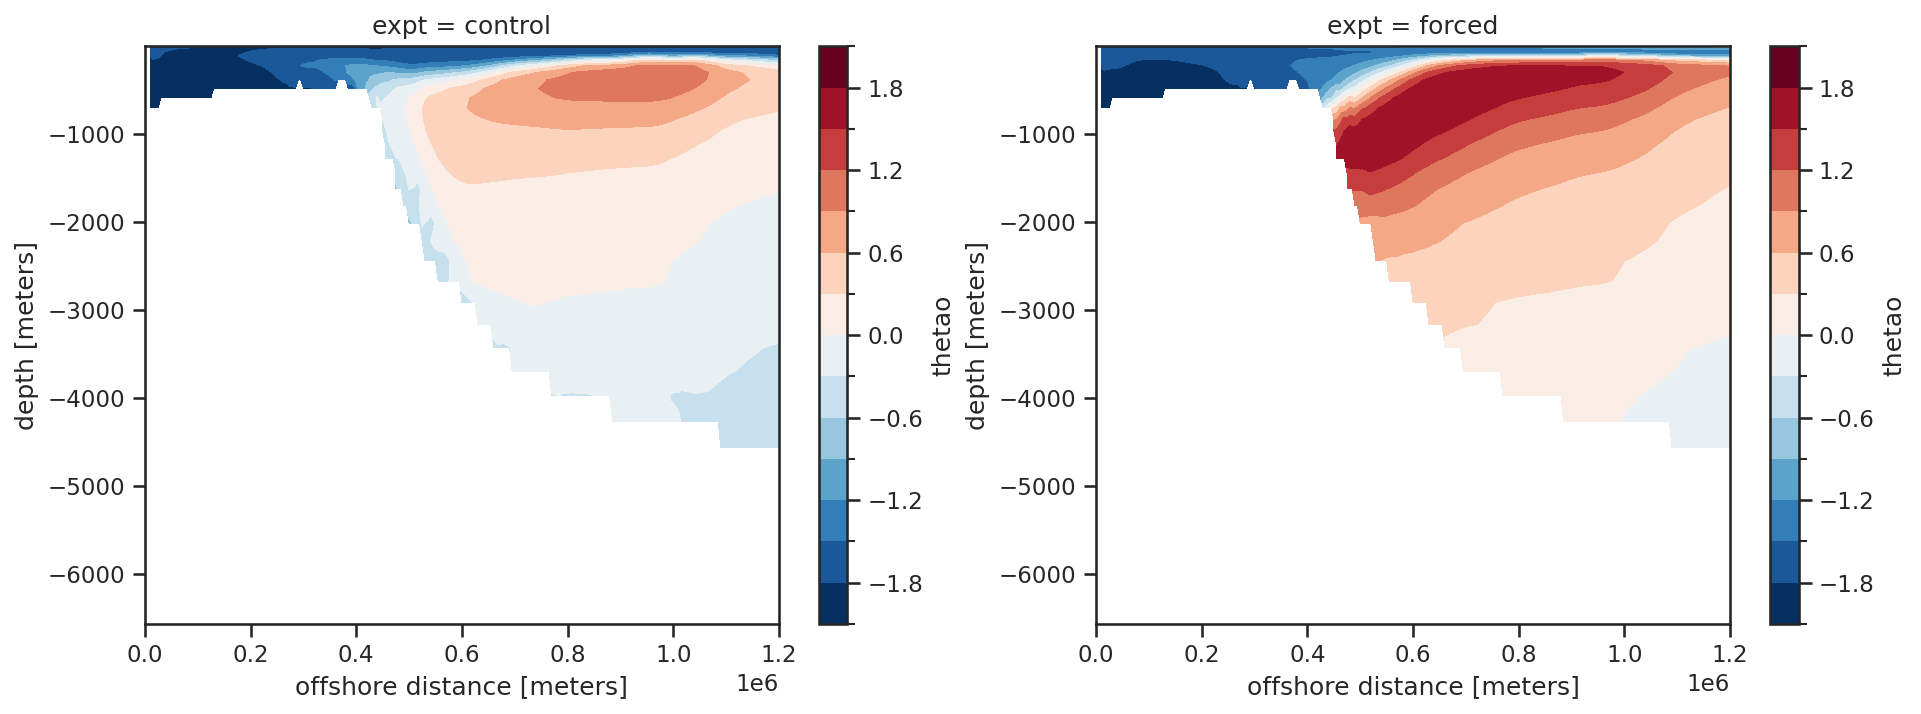

In [19]:
fig, ax = plt.subplots(1,2, figsize = (15, 5))
time_mean_var = time_mean_transects.thetao
time_mean_var.sel(expt = "control").plot.contourf(ax = ax[0], yincrease = True, levels= 15)
time_mean_var.sel(expt = "forced").plot.contourf(ax = ax[1],yincrease = True, levels= 15)

for a in ax: 
    a.set_ylabel("depth [meters]")
    a.set_xlabel("offshore distance [meters]")


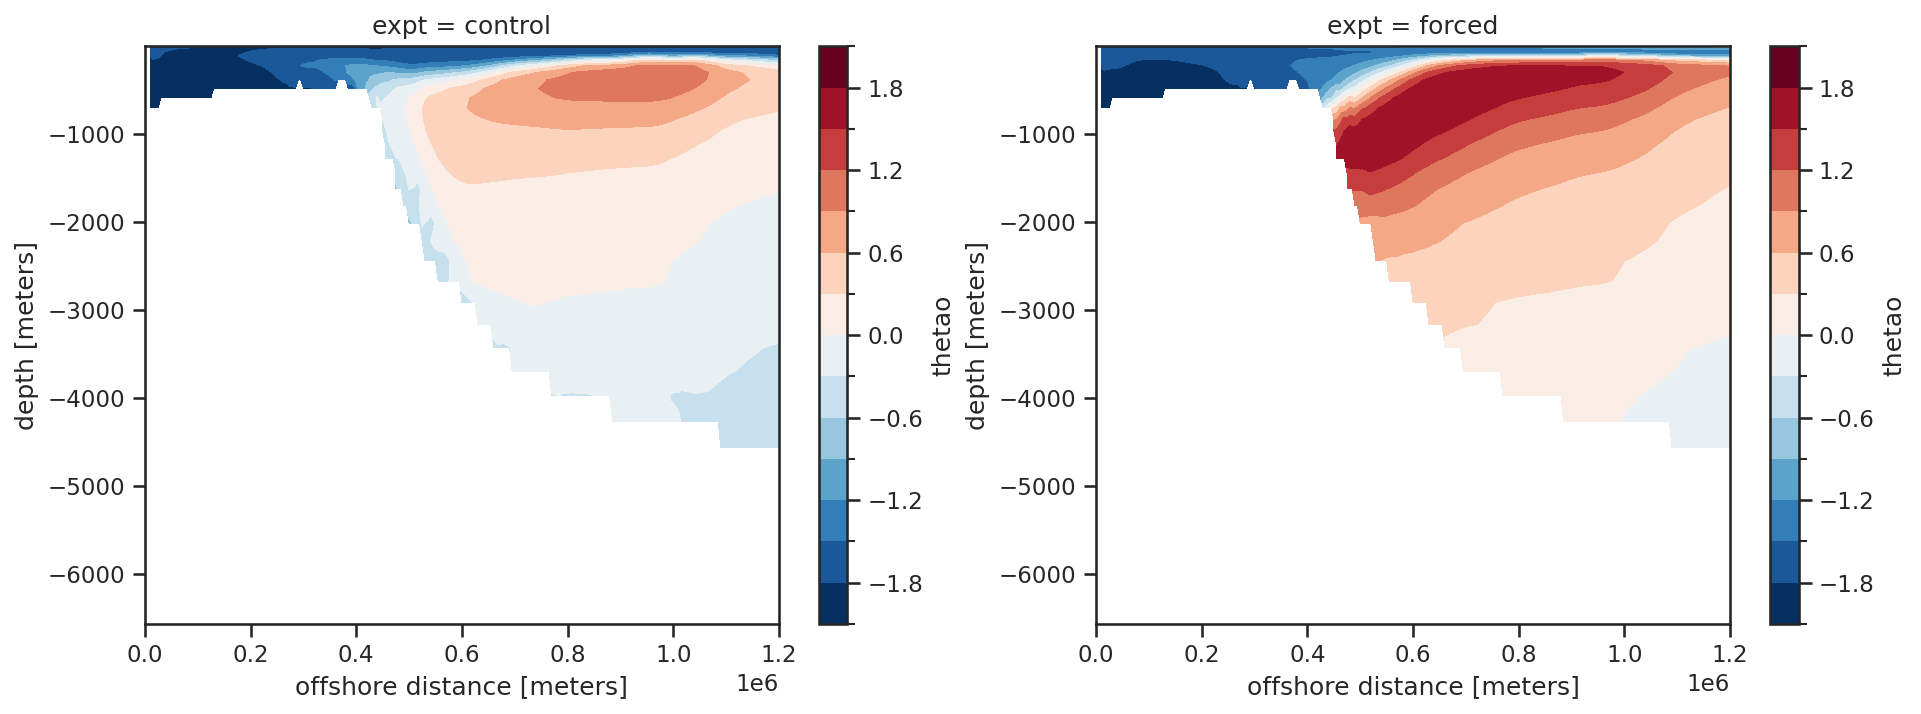

In [20]:
fig, ax = plt.subplots(1,2, figsize = (15, 5))
time_mean_var = time_mean_transects.thetao
time_mean_var.sel(expt = "control").plot.contourf(ax = ax[0], yincrease = True, levels= 15)
time_mean_var.sel(expt = "forced").plot.contourf(ax = ax[1],yincrease = True, levels= 15)

for a in ax: 
    a.set_ylabel("depth [meters]")
    a.set_xlabel("offshore distance [meters]")


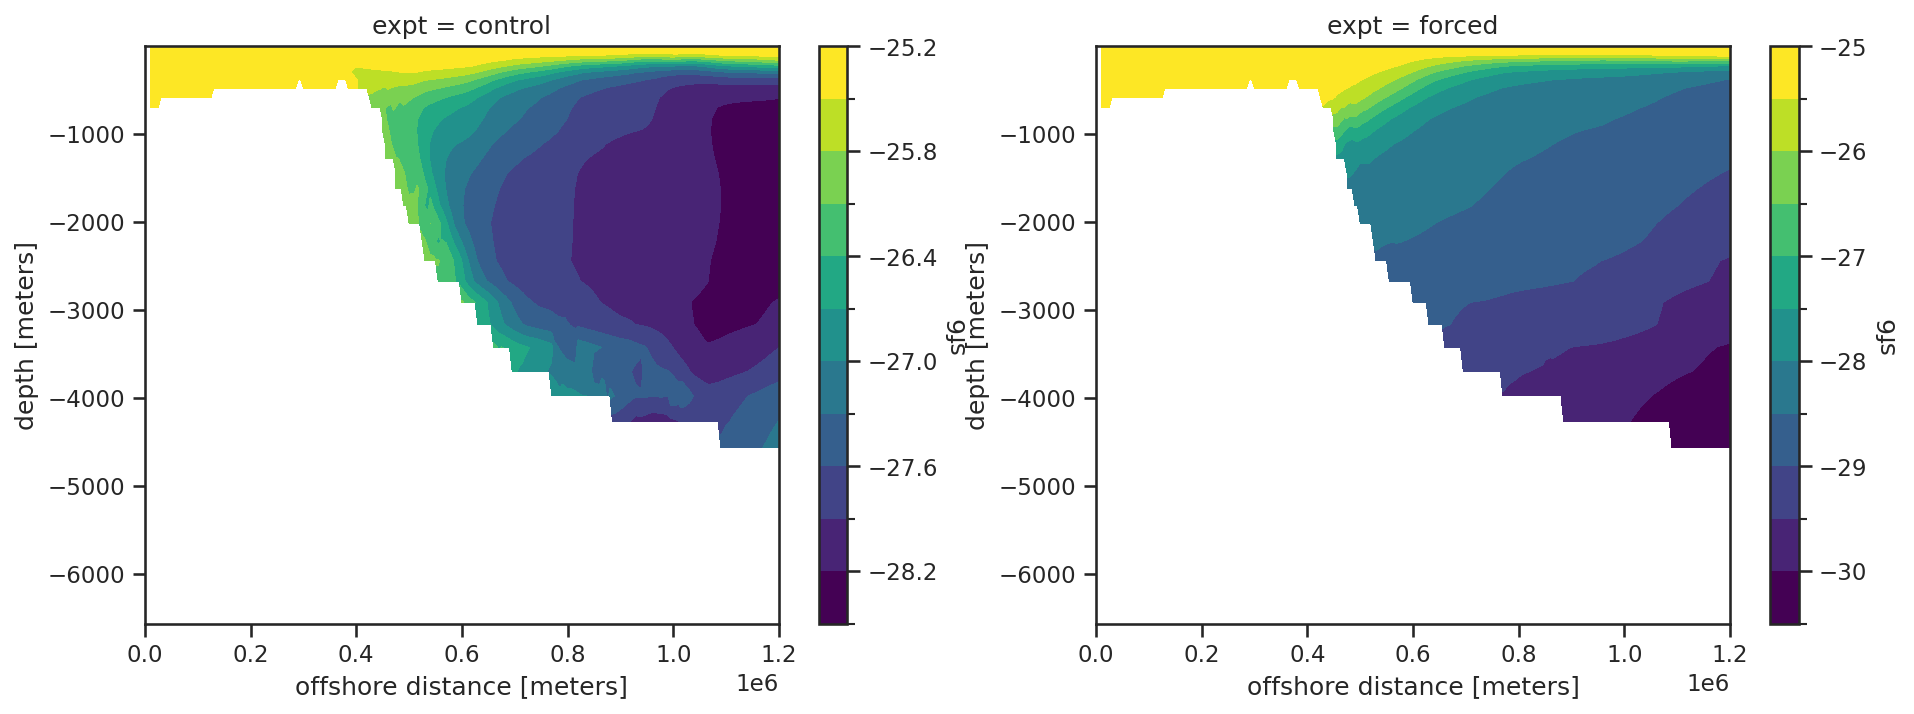

In [21]:
fig, ax = plt.subplots(1,2, figsize = (15, 5))
time_mean_var = np.log(time_mean_transects.sf6)
time_mean_var.sel(expt = "control").plot.contourf(ax = ax[0], yincrease = True, levels= 12)
time_mean_var.sel(expt = "forced").plot.contourf(ax = ax[1],yincrease = True, levels= 12)

for a in ax: 
    a.set_ylabel("depth [meters]")
    a.set_xlabel("offshore distance [meters]")

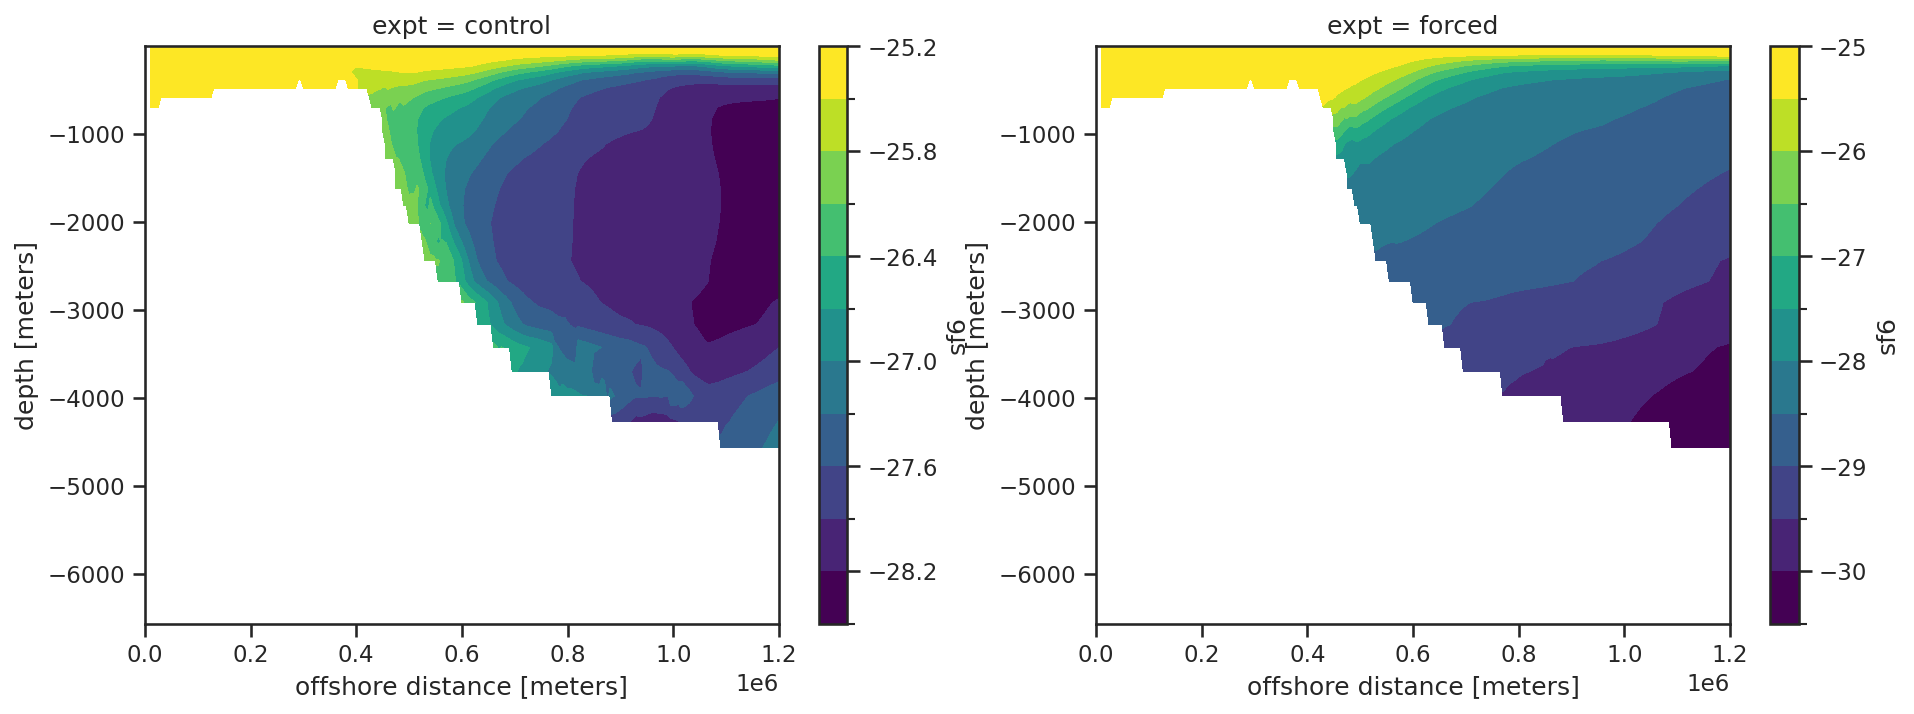

In [22]:
fig, ax = plt.subplots(1,2, figsize = (15, 5))
time_mean_var = np.log(time_mean_transects.sf6)
time_mean_var.sel(expt = "control").plot.contourf(ax = ax[0], yincrease = True, levels= 12)
time_mean_var.sel(expt = "forced").plot.contourf(ax = ax[1],yincrease = True, levels= 12)

for a in ax: 
    a.set_ylabel("depth [meters]")
    a.set_xlabel("offshore distance [meters]")

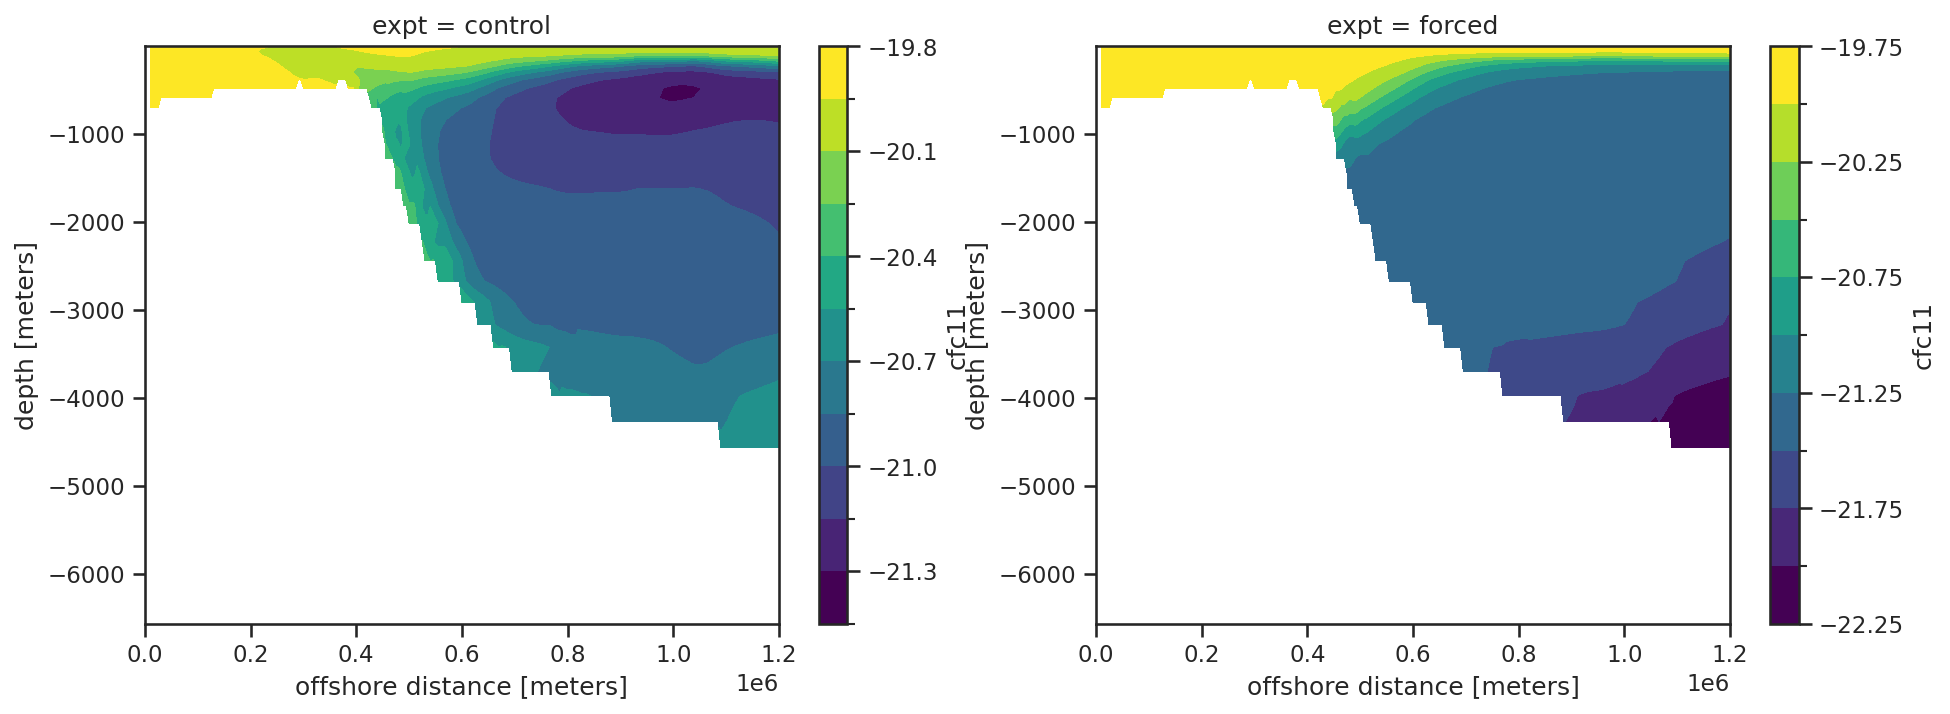

In [23]:
fig, ax = plt.subplots(1,2, figsize = (15, 5))
time_mean_var = np.log(time_mean_transects.cfc11)
time_mean_var.sel(expt = "control").plot.contourf(ax = ax[0], yincrease = True, levels= 12)
time_mean_var.sel(expt = "forced").plot.contourf(ax = ax[1],yincrease = True, levels= 12)

for a in ax: 
    a.set_ylabel("depth [meters]")
    a.set_xlabel("offshore distance [meters]")


In [24]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import FixedLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import cmocean.cm as cmo
import cmocean
import matplotlib.patheffects as pe


def _contour_label_positions_in_axes_window(
    ax,
    CS,
    window=(0.08, 0.10, 0.92, 0.90),
):
    x0, y0, x1, y1 = window
    positions = []

    for path in CS.get_paths():
        verts = path.vertices
        if verts is None or len(verts) < 2:
            continue

        verts_disp = ax.transData.transform(verts)
        verts_axes = ax.transAxes.inverted().transform(verts_disp)

        inside = (
            (verts_axes[:, 0] >= x0)
            & (verts_axes[:, 0] <= x1)
            & (verts_axes[:, 1] >= y0)
            & (verts_axes[:, 1] <= y1)
        )

        idx = np.flatnonzero(inside)
        if idx.size == 0:
            continue

        k = idx[idx.size // 2]
        positions.append(tuple(verts[k]))

    return positions


def weddell_panel_on_axes(
    fig,
    axA,
    axB,
    axC,
    axD,
    axE,
    var,
    mask,
    z=slice(0, 5000),
    avg_yrs=slice(2075, None),
    scale=1.0,
    log_scale_contours=False,
    units="",
    cbar_units=None,
    clabel_colors="k",
    levels=None,
    cmap=None,
    norm=None,
surf_loc = (190, -700),
bot_loc = (600, -3900),
    top_section_title="",
    bot_section_title="",
    top_timeseries_title="",
    bot_timeseries_title="",
    plot_contours=False,
    clabel_window=(0.08, 0.10, 0.92, 0.90),
    clabel_fontsize=11,
    transects_subset=None,
    background_spatial_values=None,
    plot_spatial=True,
    inline_annotation_color="w",
    add_units=False,
    hide_section_xlabel=False,
    add_contour_time_label=True,
):
    if plot_spatial:
        axA.add_feature(cfeature.LAND, zorder=2)
        axA.add_feature(cfeature.COASTLINE, linewidth=0.6, zorder=3)

        mA = axA.pcolormesh(
            background_spatial_values["lon"],
            background_spatial_values["lat"],
            background_spatial_values,
            transform=ccrs.PlateCarree(),
            shading="auto",
            cmap=cmo.deep,
        )

        axA.set_extent([-89, 10, -85, -61], crs=ccrs.PlateCarree())

        for i in range(transects_subset.sizes["section"]):
            axA.scatter(
                transects_subset["lon"].isel(section=i),
                transects_subset["lat"].isel(section=i),
                transform=ccrs.PlateCarree(),
                s=1,
                color="red",
                alpha=0.8,
                label="sampled sections",
            )
            if i == 0:
                axA.legend(loc="upper left")

        xticks = np.arange(-180, 181, 10)
        yticks = np.arange(-80, -49, 5)

        gl = axA.gridlines(
            crs=ccrs.PlateCarree(),
            draw_labels=True,
            linewidth=0.7,
            alpha=0.5,
        )
        gl.xlocator = FixedLocator(xticks)
        gl.ylocator = FixedLocator(yticks)
        gl.x_inline = False
        gl.y_inline = False
        gl.xpadding = 6
        gl.ypadding = 6
        gl.rotate_labels = False

        caxA = inset_axes(
            axA,
            width="92%",
            height="4%",
            loc="lower center",
            bbox_to_anchor=(0.0, -0.2, 1.0, 1.0),
            bbox_transform=axA.transAxes,
            borderpad=0.0,
        )
        cbA = fig.colorbar(mA, cax=caxA, orientation="horizontal")
        cbA.set_label("depth [m]")

        axA.text(
            0.98,
            0.02,
            "A",
            transform=axA.transAxes,
            ha="right",
            va="bottom",
            fontsize=30,
            fontweight="bold",
            color="k",
            zorder=30,
        )
    else:
        axA.set_axis_off()

    var = var.sel(z_l=z) * scale
    v = var.sel(year=avg_yrs)
    y0, y1 = int(v.year.min()), int(v.year.max())
    v = v.mean("year")

    if log_scale_contours:
        v = np.log(v)

    if levels is None:
        a = np.asarray(v).ravel()
        a = a[np.isfinite(a)]
        levels = np.linspace(a.min(), a.max(), 21) if a.size else 21

    axB.contourf(
        v.transect_length,
        np.abs(v.z_l),
        v.sel(expt="control"),
        levels=levels,
        cmap=cmap,
        norm=norm,
        extend="both",
    )
    axC.contourf(
        v.transect_length,
        np.abs(v.z_l),
        v.sel(expt="forced"),
        levels=levels,
        cmap=cmap,
        norm=norm,
        extend="both",
    )

    if plot_contours:
        CSB = axB.contour(
            v.transect_length,
            np.abs(v.z_l),
            v.sel(expt="control"),
            levels=levels,
            colors=clabel_colors,
            extend="both",
        )
        posB = _contour_label_positions_in_axes_window(
            axB,
            CSB,
            window=clabel_window,
        )
        if posB:
            axB.clabel(CSB, CSB.levels, manual=posB, fontsize=clabel_fontsize)
        else:
            axB.clabel(CSB, CSB.levels, fontsize=clabel_fontsize)

        CSC = axC.contour(
            v.transect_length,
            np.abs(v.z_l),
            v.sel(expt="forced"),
            levels=levels,
            colors=clabel_colors,
            extend="both",
        )
        posC = _contour_label_positions_in_axes_window(
            axC,
            CSC,
            window=clabel_window,
        )
        if posC:
            axC.clabel(CSC, CSC.levels, manual=posC, fontsize=clabel_fontsize)
        else:
            axC.clabel(CSC, CSC.levels, fontsize=clabel_fontsize)

    for a in (axB, axC):
        a.invert_yaxis()

    axB.set_title(top_section_title, loc="left", fontweight="bold")
    axC.set_title(bot_section_title, loc="left", fontweight="bold")

    if add_contour_time_label:
        for ax in (axB, axC):
            ax.text(
                0.02,
                0.05,
                f"{y0}-{y1}",
                transform=ax.transAxes,
                ha="left",
                va="bottom",
                fontsize=14,
                color="w",
                bbox=dict(
                    boxstyle="round,pad=0.2",
                    fc="k",
                    ec="none",
                    alpha=0.45,
                ),
                zorder=20,
            )

    if cbar_units is None:
        cbar_units = units

    if add_units:
        inline_label = cbar_units if log_scale_contours else units
        for ax in (axB, axC):
            ax.text(
                0.02,
                0.14,
                f"Units: {inline_label}",
                transform=ax.transAxes,
                ha="left",
                va="bottom",
                color=inline_annotation_color,
                fontsize=10,
                bbox=dict(
                    boxstyle="round,pad=0.2",
                    fc="k",
                    ec="none",
                    alpha=0.45,
                ),
                zorder=20,
            )

    lat_s, z_s = surf_loc
    lat_b, z_b = bot_loc

    for a in (axB, axC):
        a.plot(
            lat_s,
            np.abs(z_s),
            marker="*",
            ms=20,
            mfc="yellow",
            mec="k",
            mew=0.8,
            zorder=10,
        )
        a.text(
            lat_s - 180.0,
            np.abs(z_s - 600),
            "shelf",
            ha="left",
            va="center",
            color="yellow",
            fontweight="bold",
            zorder=11,
            path_effects=[
                pe.Stroke(linewidth=1.0, foreground="black"),
                pe.Normal(),
            ],
        )
        a.plot(
            lat_b,
            np.abs(z_b),
            marker="o",
            ms=16,
            mfc="yellow",
            mec="k",
            mew=0.8,
            zorder=10,
        )
        a.text(
            lat_b - 260.0,
            np.abs(z_b - 100),
            "slope",
            ha="left",
            va="center",
            color="yellow",
            fontweight="bold",
            zorder=11,
            path_effects=[
                pe.Stroke(linewidth=1.0, foreground="black"),
                pe.Normal(),
            ],
        )

    axB.set_ylabel("Depth [m]")
    axC.set_ylabel("Depth [m]")

    if hide_section_xlabel:
        axB.set_xlabel("")
        axC.set_xlabel("")
        axB.tick_params(labelbottom=False)
        axC.tick_params(labelbottom=False)
    else:
        axB.set_xlabel("")
        axC.set_xlabel("Offshore Distance [km]")
        axB.tick_params(labelbottom=False)

    axB.set_facecolor("grey")
    axC.set_facecolor("grey")

    colors = {"control": "k", "forced": "r"}
    labels = {"control": "piControl", "forced": "Historical/SSP5-8.5"}

    ts = var.interp(transect_length=lat_s, z_l=z_s, method="linear",
    kwargs={"fill_value": np.nan},)
    tb = var.interp(transect_length=lat_b, z_l=z_b, method="linear",
    kwargs={"fill_value": np.nan},)

    for expt, c in colors.items():
        axD.plot(ts.year, ts.sel(expt=expt), label=labels[expt], c=c)
        axE.plot(tb.year, tb.sel(expt=expt), label=labels[expt], c=c)

    axD.tick_params(labelbottom=False)
    axD.set_title(top_timeseries_title, loc="left", fontweight="bold")
    axE.set_title(bot_timeseries_title, loc="left", fontweight="bold")
    axD.set_ylabel("[" + units + "]")
    axE.set_ylabel("[" + units + "]")
    axD.grid(alpha=0.3)
    axE.grid(alpha=0.3)
    axD.legend(frameon=False)
    axE.legend(frameon=False)

    return {
        "axA": axA,
        "axB": axB,
        "axC": axC,
        "axD": axD,
        "axE": axE,
    }

/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.11/site-packages/numbagg/decorators.py:245: RuntimeWarning: invalid value encountered in nanmean
  return self.gufunc(target=self.target)(*arrays, axis=-1)
/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.11/site-packages/numbagg/decorators.py:245: RuntimeWarning: invalid value encountered in nanmean
  return self.gufunc(target=self.target)(*arrays, axis=-1)


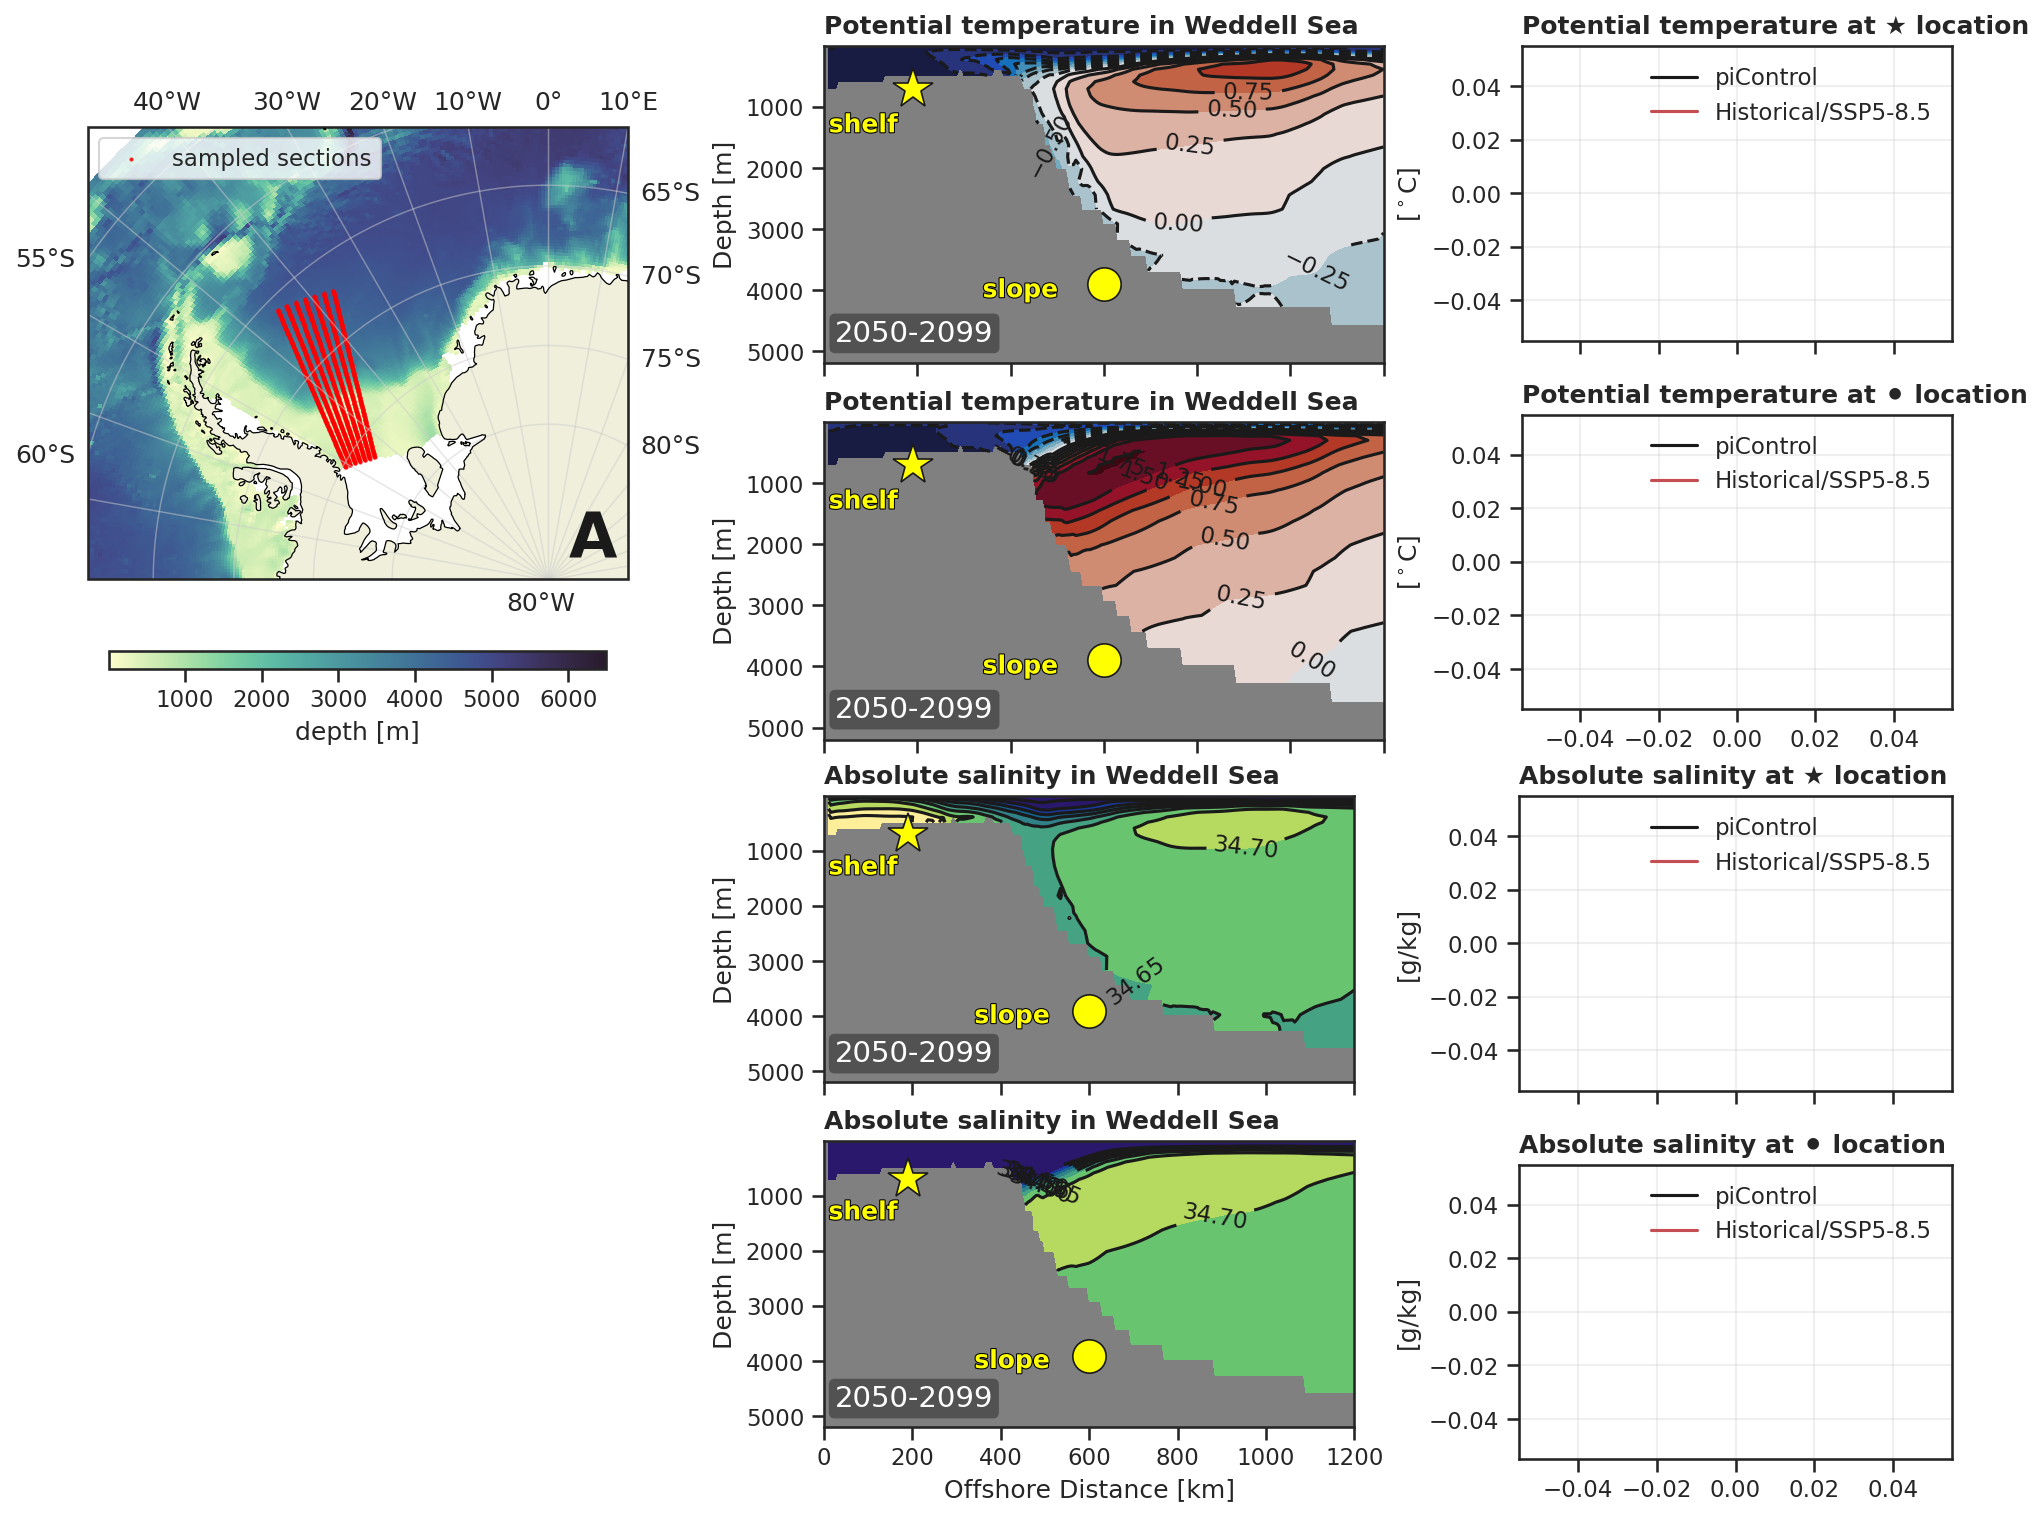

In [25]:
surf_loc = (190, -700)
bot_loc = (600, -3900)

clabel_window = (0.10, 0.12, 0.90, 0.88)

fig = plt.figure(figsize=(13, 10), constrained_layout=True)
gs = fig.add_gridspec(
    2, 3,
    width_ratios=(0.95, 1.2, 1.0),
    height_ratios=(1.0, 1.0),
    hspace=0.18,
)

gs_mid1 = gs[0, 1].subgridspec(2, 1, hspace=0.02)
gs_right1 = gs[0, 2].subgridspec(2, 1, hspace=0.04)
gs_mid2 = gs[1, 1].subgridspec(2, 1, hspace=0.02)
gs_right2 = gs[1, 2].subgridspec(2, 1, hspace=0.04)

axA1 = fig.add_subplot(gs[0, 0], projection=ccrs.SouthPolarStereo())
axB1 = fig.add_subplot(gs_mid1[0, 0])
axC1 = fig.add_subplot(gs_mid1[1, 0], sharex=axB1)
axD1 = fig.add_subplot(gs_right1[0, 0])
axE1 = fig.add_subplot(gs_right1[1, 0], sharex=axD1)

axA2 = fig.add_subplot(gs[1, 0], projection=ccrs.SouthPolarStereo())
axB2 = fig.add_subplot(gs_mid2[0, 0])
axC2 = fig.add_subplot(gs_mid2[1, 0], sharex=axB2)
axD2 = fig.add_subplot(gs_right2[0, 0])
axE2 = fig.add_subplot(gs_right2[1, 0], sharex=axD2)

levels1 = np.arange(-2, 2 + 0.01, 0.25)
cmap1 = plt.get_cmap(cmo.balance, len(levels1) - 1)
norm1 = BoundaryNorm(levels1, ncolors=cmap1.N, clip=True)

var1 = avg_transects.thetao.copy()
var1.coords["transect_length"] = 1e-3 * avg_transects.coords["transect_length"].values

axs1 = weddell_panel_on_axes(
    fig,
    axA1,
    axB1,
    axC1,
    axD1,
    axE1,
    var1,
    boundary_mask,
    z=slice(-5500, 0),
    avg_yrs=slice(2050, None),
    levels=levels1,
    units=r"$^\circ$C",
    cmap=cmap1,
    norm=norm1,
    plot_contours=True,
    clabel_colors="k",
    clabel_window=clabel_window,
    surf_loc=surf_loc,
    bot_loc=bot_loc,
    top_section_title="Potential temperature in Weddell Sea",
    bot_section_title="Potential temperature in Weddell Sea",
    top_timeseries_title="Potential temperature at ★ location",
    bot_timeseries_title="Potential temperature at ⚫ location",
    transects_subset=transects_subset,
    background_spatial_values=ds["deptho"],
    plot_spatial=True,
    hide_section_xlabel=True,
)

levels2 = np.arange(34.4, 34.8 + 0.01, 0.05)
cmap2 = plt.get_cmap(cmo.haline, len(levels2) - 1)
norm2 = BoundaryNorm(levels2, ncolors=cmap2.N, clip=True)

var2 = avg_transects.so.copy()
var2.coords["transect_length"] = 1e-3 * avg_transects.coords["transect_length"].values

axs2 = weddell_panel_on_axes(
    fig,
    axA2,
    axB2,
    axC2,
    axD2,
    axE2,
    var2,
    boundary_mask,
    z=slice(-5500, 0),
    avg_yrs=slice(2050, None),
    levels=levels2,
    units="g/kg",
    cmap=cmap2,
    norm=norm2,
    plot_contours=True,
    clabel_colors="k",
    clabel_window=clabel_window,
    surf_loc=surf_loc,
    bot_loc=bot_loc,
    top_section_title="Absolute salinity in Weddell Sea",
    bot_section_title="Absolute salinity in Weddell Sea",
    top_timeseries_title="Absolute salinity at ★ location",
    bot_timeseries_title="Absolute salinity at ⚫ location",
    transects_subset=transects_subset,
    background_spatial_values=ds["deptho"],
    plot_spatial=False,
    hide_section_xlabel=False,
)

# fig.savefig("plots/thetao_so_weddell_average.png", dpi=150, bbox_inches="tight")
plt.show()

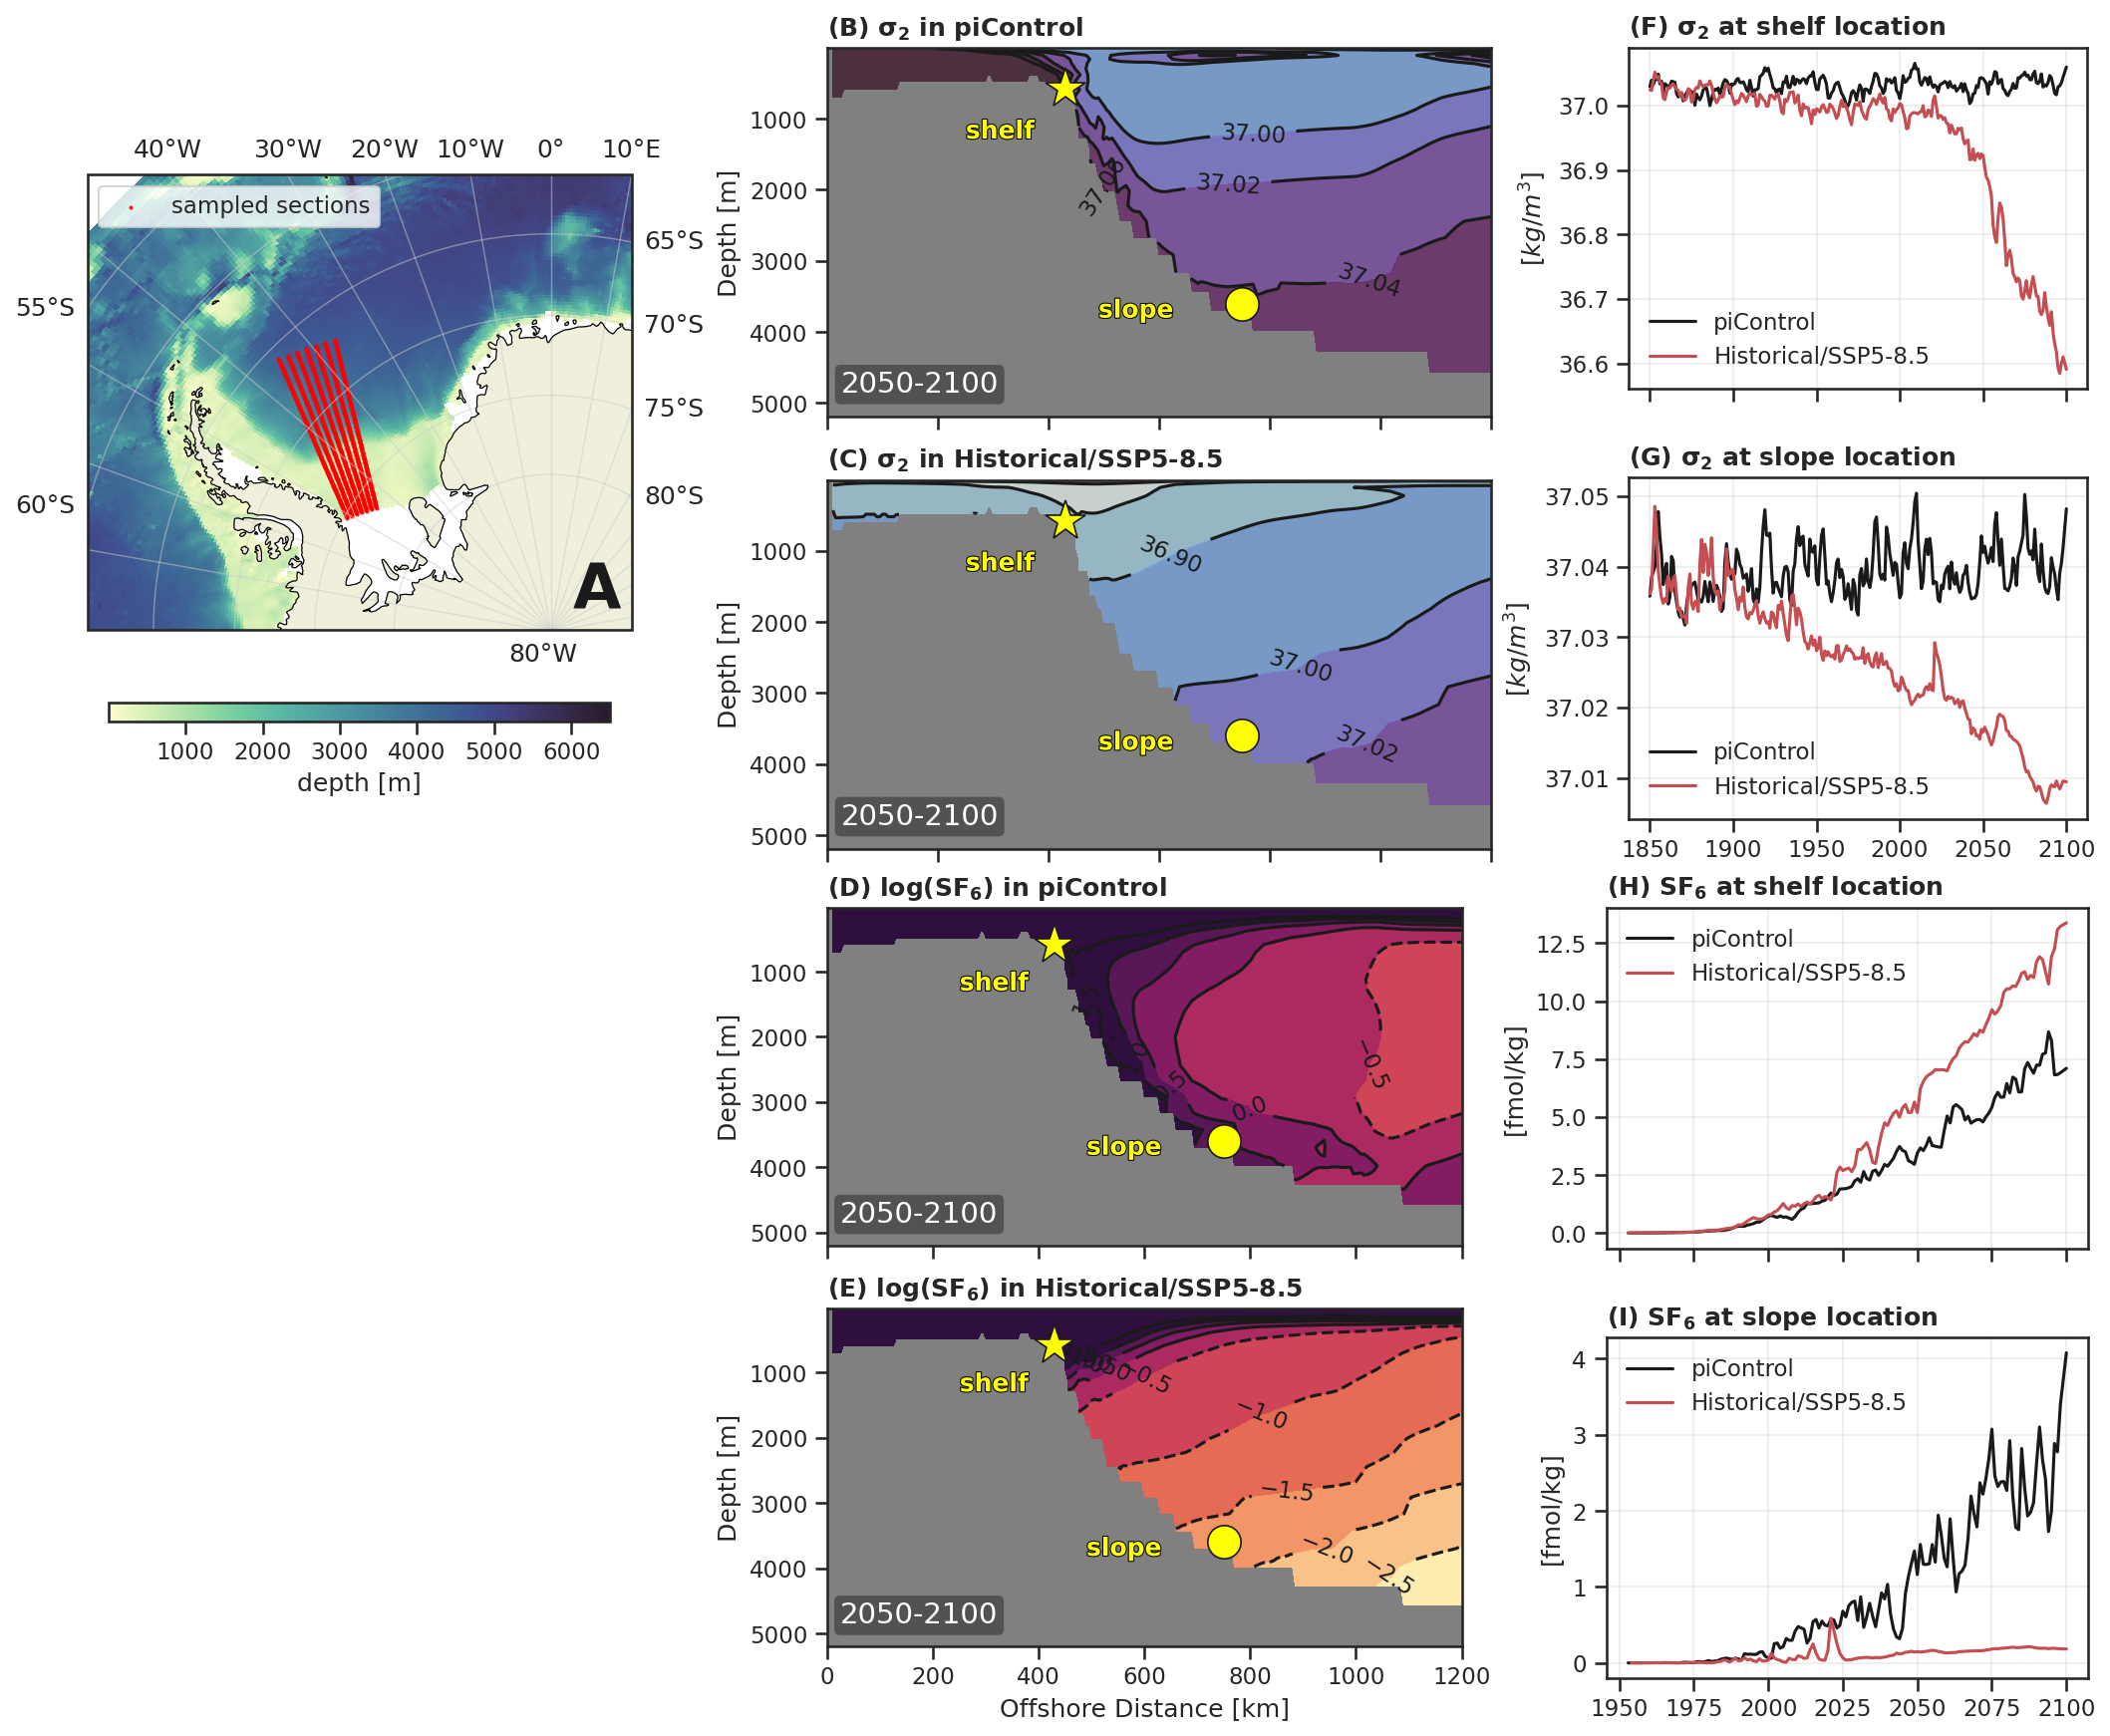

In [26]:
surf_loc = (430, -580)
bot_loc = (750, -3600)

clabel_window = (0.10, 0.12, 0.90, 0.88)

fig = plt.figure(figsize=(14, 11.5), constrained_layout=True)
gs = fig.add_gridspec(
    2, 3,
    width_ratios=(0.9, 1.3, 1.0),
    height_ratios=(1.0, 1.0),
    hspace=0.18,
)

gs_mid1 = gs[0, 1].subgridspec(2, 1, hspace=0.02)
gs_right1 = gs[0, 2].subgridspec(2, 1, hspace=0.05)
gs_mid2 = gs[1, 1].subgridspec(2, 1, hspace=0.02)
gs_right2 = gs[1, 2].subgridspec(2, 1, hspace=0.05)

axA1 = fig.add_subplot(gs[0, 0], projection=ccrs.SouthPolarStereo())
axB1 = fig.add_subplot(gs_mid1[0, 0])
axC1 = fig.add_subplot(gs_mid1[1, 0], sharex=axB1)
axD1 = fig.add_subplot(gs_right1[0, 0])
axE1 = fig.add_subplot(gs_right1[1, 0], sharex=axD1)

axA2 = fig.add_subplot(gs[1, 0], projection=ccrs.SouthPolarStereo())
axB2 = fig.add_subplot(gs_mid2[0, 0])
axC2 = fig.add_subplot(gs_mid2[1, 0], sharex=axB2)
axD2 = fig.add_subplot(gs_right2[0, 0])
axE2 = fig.add_subplot(gs_right2[1, 0], sharex=axD2)

levels1 = [36.5, 36.7, 36.9, 37.00, 37.02, 37.04, 37.06, 37.08]
cmap1 = plt.get_cmap(cmocean.tools.lighten(cmo.dense, 0.7), len(levels1) - 1)
norm1 = BoundaryNorm(levels1, ncolors=cmap1.N, clip=True)

avg_trans = avg_transects.interp(year = np.arange(1850, 2101),method="linear",
    kwargs={"fill_value": "extrapolate"})

var1 = 1 * avg_trans.sigma2_offline
var1.coords["transect_length"] = 1e-3 * avg_transects.coords["transect_length"].values

axs1 = weddell_panel_on_axes(
    fig,
    axA1,
    axB1,
    axC1,
    axD1,
    axE1,
    var1,
    boundary_mask,
    z=slice(-5500, 0),
    avg_yrs=slice(2050, None),
    levels=levels1,
    units=r"$kg/m^3$",
    cmap=cmap1,
    norm=norm1,
    plot_contours=True,
    clabel_colors="k",
    clabel_window=clabel_window,
    surf_loc=surf_loc,
    bot_loc=bot_loc,
    top_section_title=r"(B) $\mathbf{\sigma_2}$ in piControl",
    bot_section_title=r"(C) $\mathbf{\sigma_2}$ in Historical/SSP5-8.5",
    top_timeseries_title=r"(F) $\mathbf{\sigma_2}$" + " at shelf location",
    bot_timeseries_title=r"(G) $\mathbf{\sigma_2}$" + " at slope location",
    transects_subset=transects_subset,
    background_spatial_values=ds["deptho"],
    plot_spatial=True,
    hide_section_xlabel=True,
)

levels2 = np.arange(-3, 1.5 + 0.01, 0.5)
cmap2 = plt.get_cmap(cmo.matter, len(levels2) - 1)
norm2 = BoundaryNorm(levels2, ncolors=cmap2.N, clip=True)

var2 = avg_trans.sf6 * 1e12 / 1035 * 1e3
var2.coords["transect_length"] = 1e-3 * avg_transects.coords["transect_length"].values

axs2 = weddell_panel_on_axes(
    fig,
    axA2,
    axB2,
    axC2,
    axD2,
    axE2,
    var2,
    boundary_mask,
    z=slice(-5500, -10),
    avg_yrs=slice(2050, None),
    levels=levels2,
    units="fmol/kg",
    cbar_units=r"$log(fmol/kg)$",
    cmap=cmap2,
    norm=norm2,
    log_scale_contours=True,
    plot_contours=True,
    clabel_colors="k",
    clabel_window=clabel_window,
    surf_loc=surf_loc,
    bot_loc=bot_loc,
    top_section_title=r"(D) log(SF$\mathbf{_6}$) in piControl",
    bot_section_title=r"(E) log(SF$\mathbf{_6}$) in Historical/SSP5-8.5",
    top_timeseries_title=r"(H) SF$\mathbf{_6}$ at shelf location",
    bot_timeseries_title=r"(I) SF$\mathbf{_6}$ at slope location",
    transects_subset=transects_subset,
    background_spatial_values=ds["deptho"],
    plot_spatial=False,
    hide_section_xlabel=False,
)

fig.savefig("plots/6.Weddell_density_and_sf6.png", dpi=350, bbox_inches="tight")

In [27]:
def calc_p_from_z(z, lat):
    """Calculates pressure from depth z (must be negative downwards) and latitude."""
    return xr.apply_ufunc(
        gsw.p_from_z,
        z, lat,
        dask='parallelized',
        output_dtypes=[float]
    )
def calc_sigma2(SA, CT):
    """Calculates sigma2 using apply_ufunc for safe Dask/Xarray handling."""
    return xr.apply_ufunc(
        gsw.sigma2,
        SA, CT,
        dask='parallelized',
        output_dtypes=[float]
    )

def calc_rho_alpha_beta(SA, CT, p):
    """
    Calculates rho, alpha, and beta using apply_ufunc.
    gsw.rho_alpha_beta returns 3 variables, requiring output_core_dims.
    """
    return xr.apply_ufunc(
        gsw.rho_alpha_beta,
        SA, CT, p,
        dask='parallelized',
        output_core_dims=[[], [], []],
        output_dtypes=[float, float, float]
    )
    
lat_s, z_s = surf_loc
lat_b, z_b = bot_loc

avg_transects_copy = 1.0 * avg_transects
avg_transects_copy["transect_length"] = 1e-3 * avg_transects_copy.coords["transect_length"].values

avg_transects_copy['sigma2_obs'] = calc_sigma2(
    avg_transects_copy.so.astype("float64"),
    avg_transects_copy.thetao.astype("float64"))



In [28]:
from SWMT_decomposition import *
from select_max_loc import *

savedir = "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/"
datadir = lambda x="" : "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/" + x
ds_maximum_sbf = xr.open_dataset(datadir("/model/Southern_Ocean_DSW_1000m_max_SWMT.zarr"))
max_sbf_loc = ds_maximum_sbf["max_surface_boundary_flux_density"]

toTg = 1e-9 
mass_flux_units = "Tg/s"
mass_flux_units_conversion = toTg #kg to Tg 

ds_sfc = xr.open_mfdataset(datadir(f"/model/Southern_Ocean_DSW_1000m_WMT_Surface_Fluxes_sigma_slice.zarr"))
ds_sfc_SWMT = get_SWMT(ds_sfc)
Wedell_DSW_SWMT = ds_sfc_SWMT.isel(xh = slice(157, 190)).sum(["xh", "yh"])
Wedell_DSW_SWMT["SWMT_residual"] = Wedell_DSW_SWMT["SWMT_salt_residual"] + Wedell_DSW_SWMT["SWMT_heat_residual"] 

In [29]:
abyssal_sbf = Wedell_DSW_SWMT.sel(sigma2_l_target = slice(20, 38.1))["SWMT"].fillna(0.0)
max_locations = abyssal_sbf.argmax("sigma2_l_target")

control_max = abyssal_sbf["sigma2_l_target"][max_locations.sel(exp = "control")].rename("max_surface_boundary_flux_density")
forced_max = abyssal_sbf["sigma2_l_target"][max_locations.sel(exp = "forced")].rename("max_surface_boundary_flux_density")

max_sbf_weddell_loc = xr.concat([control_max, forced_max], dim = "exp").compute()
max_sbf_weddell = toTg * select_from_location(Wedell_DSW_SWMT, max_sbf_weddell_loc).compute()

/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.11/site-packages/distributed/client.py:3375: UserWarning: Sending large graph of size 11.19 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [30]:
window = 2100
# select locations
ts = avg_transects_copy.interp(transect_length=lat_s, z_l=z_s).sel(year = slice(None, window))
tb = avg_transects_copy.interp(transect_length=lat_b, z_l=z_b).sel(year = slice(None, window))

time = ts.year
# Point 1 (Upper)
SA_1 = ts["so"].astype("float64")
CT_1 = ts["thetao"]
PT_1 = ts['sigma2_obs']
# Point 2 (Lower)
SA_2 = tb["so"]
CT_2 =  tb["thetao"]
PT_2 = tb['sigma2_obs']

# Actual Sigma-2 Difference
#sigma2_obs is biased high compared to sigma2_offline (i.e., sigma2_obs is lighter than sigma2_offline
#but the differences (PT_2 - PT_1) are approximately the same.
density_difference_ds = (-(PT_2 - PT_1)).to_dataset(name = "actual_sigma2_diff") 

# Linear Reconstruction Components
delta_CT =  -(CT_2 - CT_1)
delta_SA = -(SA_2 - SA_1)

mid_CT = (CT_2 + CT_1) / 2
mid_SA = (SA_2 + SA_1) / 2
p_ref = 2000.0 # sigma2 reference pressure

rho_mid, alpha_mid, beta_mid = calc_rho_alpha_beta(mid_SA, mid_CT, p_ref)

density_difference_ds["T_contribution"] = (-rho_mid * alpha_mid * delta_CT)
density_difference_ds["S_contribution"] = rho_mid * beta_mid * delta_SA

density_difference_ds["reconstructed_sigma2_diff"] = density_difference_ds["T_contribution"] + density_difference_ds["S_contribution"]


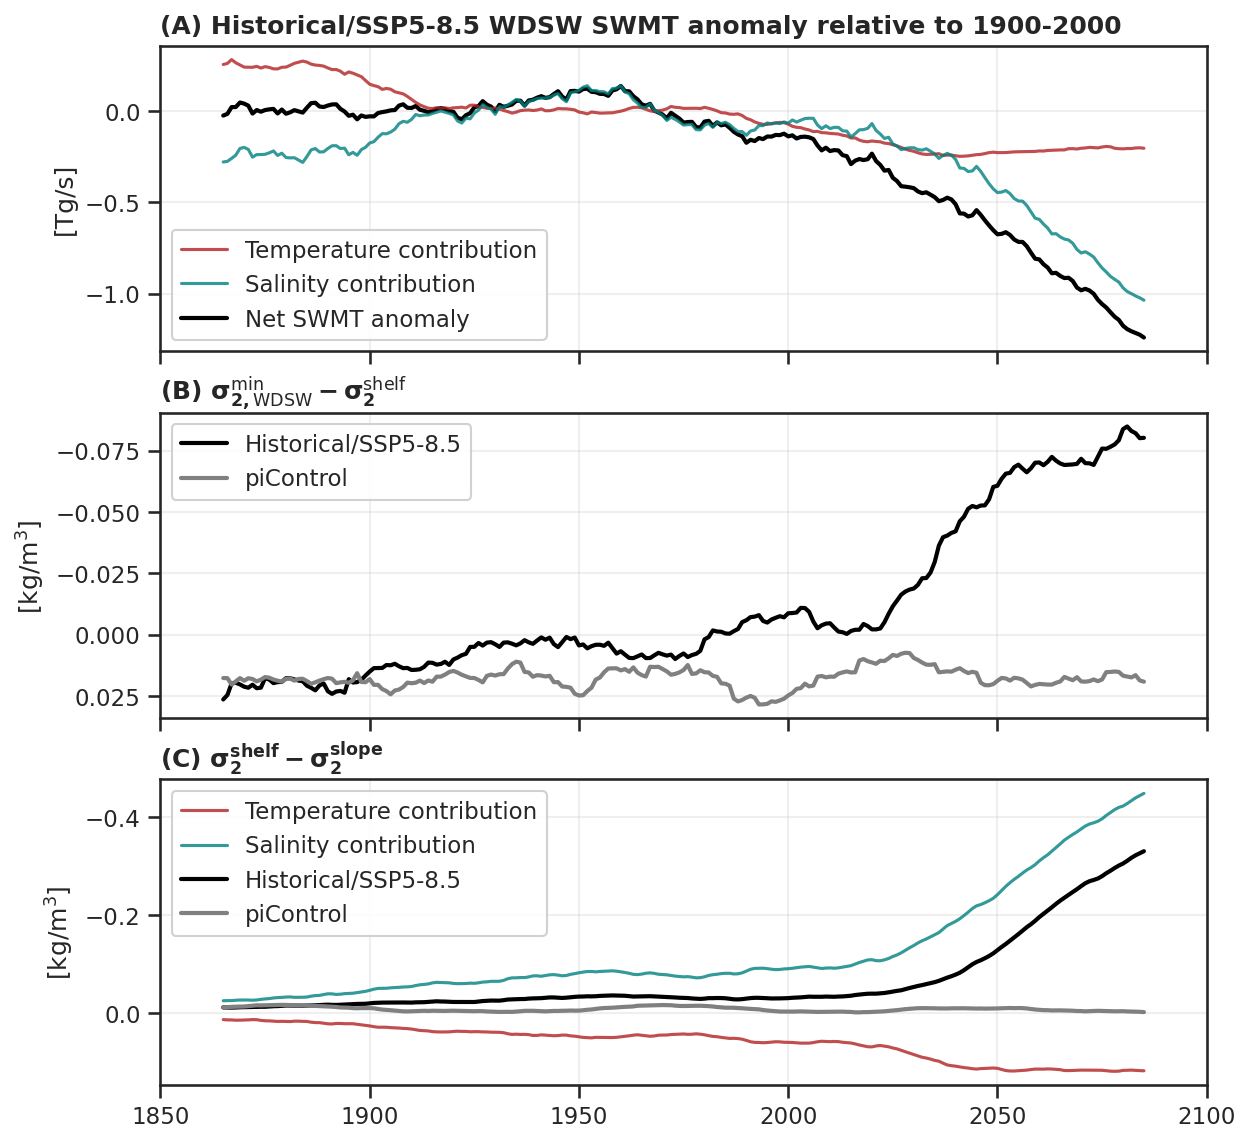

In [31]:
rolling_window = 30
center = True
# ==========================================
# 4. SINGLE AXIS VISUALIZATION
# ==========================================
fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex = True)

ax = axes[0]

forced_SWMT = max_sbf_weddell.sel(exp = "forced")
forced_SWMT = forced_SWMT - max_sbf_weddell.sel(exp = "forced").sel(year = slice(1900, 2000)).mean("year")
    
forced_SWMT = forced_SWMT.rolling(year = rolling_window, center = center).mean("year")
SWMT_times = forced_SWMT.year
ax.plot(SWMT_times, forced_SWMT["SWMT_heat"], label='Temperature contribution', color='firebrick', alpha=0.8, linewidth=1.5, zorder = 10)
ax.plot(SWMT_times, forced_SWMT["SWMT_salt"], label='Salinity contribution', color='teal', alpha=0.8, linewidth=1.5, zorder = 10)
ax.plot(SWMT_times, forced_SWMT["SWMT"], label = "Net SWMT anomaly", color='black', linewidth=2)

# forced_SWMT["SWMT_residual"].plot(ax = ax)
ax.legend(loc='best', framealpha=0.9)
ax.grid(alpha=0.3)
ax.set_xlabel('')
ax.set_ylabel(r'[Tg/s]')
ax.set_title("(A) Historical/SSP5-8.5 WDSW SWMT anomaly relative to 1900-2000", loc="left", fontweight = "bold")
# ax.set_xlim(-3, None)

ax = axes[2]
# Plot the individual T and S contributions
wedell_density_diff = density_difference_ds.sel(expt = "forced").rolling(year = rolling_window, center = center).mean("year")
ax.plot(time, wedell_density_diff["T_contribution"], label='Temperature contribution', color='firebrick', alpha=0.8, linewidth=1.5, zorder = 10)
ax.plot(time, wedell_density_diff["S_contribution"], label='Salinity contribution', color='teal', alpha=0.8, linewidth=1.5, zorder = 10)

# Plot the total differences (Actual and Reconstructed)
# Make 'Actual' thick and solid, 'Reconstructed' dashed and slightly thinner to lay on top
ax.plot(time, wedell_density_diff["actual_sigma2_diff"], 
        label=r"Historical/SSP5-8.5", color='black', linewidth=2)
wedell_density_diff = density_difference_ds.sel(expt = "control").rolling(year = rolling_window, center = center).mean("year")
ax.plot(time, wedell_density_diff["actual_sigma2_diff"], 
        label=r"piControl", color='grey', linewidth=2)

# ax.plot(time, wedell_density_diff["reconstructed_sigma2_diff"], label='linear reconstruction of $\Delta\sigma_2$', color='grey', linestyle='--', linewidth=2.0)

# Formatting
# ax.set_xlabel('year')
ax.set_xlabel('')
ax.set_ylabel(r'[kg/m$^{3}$]')
# ax.set_title("(C)", loc="left", fontweight = "bold")
ax.set_title("(C) " + r"$\mathbf{\sigma^{\mathbf{shelf}}_2 - \sigma^{\mathbf{slope}}_2}$", loc="left", fontweight = "bold")

ax.legend(loc='best', framealpha=0.9)
ax.grid(alpha=0.3)
ax.invert_yaxis()
ax = axes[1]

swmt_shelf_density_difference = max_sbf_weddell_loc - ts['sigma2_obs'].rename({"expt":"exp"})
swmt_shelf_density_difference = swmt_shelf_density_difference.rolling(year = rolling_window, center = center).mean("year")

ax.plot(swmt_shelf_density_difference.year, swmt_shelf_density_difference.sel(exp = "forced"), color='black', 
linewidth=2, label= r"Historical/SSP5-8.5")

ax.plot(swmt_shelf_density_difference.year, swmt_shelf_density_difference.sel(exp = "control"), color='grey', 
linewidth=2, label= r"piControl")

ax.legend(loc='best', framealpha=0.9)
ax.grid(alpha=0.3)
ax.set_xlabel('')
ax.set_ylabel(r'[kg/m$^{3}$]')
# ax.set_title("(B) ", loc="left", fontweight = "bold")
ax.set_title("(B) " + r"$\mathbf{\sigma_{2,\substack{\mathrm{WDSW}}}^{\min} - \sigma^{\mathrm{shelf}}_2}$", loc="left", fontweight = "bold")

ax.set_xlim(1850, 2100)
ax.invert_yaxis()
fig.savefig("plots/7.Weddell_density_SWMT_comparison.png", dpi = 350, bbox_inches = "tight")

In [32]:
calc_sigma2(
    avg_transects_copy.so.astype("float64"),
    avg_transects_copy.thetao.astype("float64")).values.dtype

dtype('float64')

In [33]:
calc_sigma2(
    avg_transects_copy.so.astype("float32"),
    avg_transects_copy.thetao.astype("float32")).values.dtype

dtype('float64')